# 🎛️ Ray Tune — Parallel Hyperparameter Tuning with Early Stopping

> **What you'll learn:** how to run many hyperparameter trials in parallel with the modern `Tuner` API, report metrics and checkpoints every epoch, stop bad trials early with **ASHA** and **HyperBand** (and *measure* the compute saved), evolve hyperparameters during training with **Population Based Training**, plug in Optuna's TPE sampler safely, give trials the right CPUs/GPUs, survive crashes, and analyse results — on real data, with a PyTorch model and a gradient-boosting model.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Optuna](01_Optuna.ipynb) (trials, samplers, pruning) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (training loops, optimizers) |
| **Tested with** | Python 3.12 · ray[tune] 2.58 · optuna 5.0 · torch 2.14 (CPU) · lightgbm 4.7 · scikit-learn 1.9 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ High for ML-platform / MLE roles — "explain successive halving and ASHA", "search algorithm vs scheduler", "how does PBT work?", "how would you tune a model on a cluster with a fixed GPU budget?", "why did parallel tuning get slower?" |

## 🤔 What Is Ray Tune?

Tuning hyperparameters (learning rate, layer width, tree depth, …) means training the same model many times with different settings and keeping the best. **Ray Tune** is a library that runs those training runs — called **trials** — **in parallel** (on your laptop's cores or a whole cluster) and adds smart rules for **stopping hopeless trials early**.

**Analogy — a cooking competition.** 20 chefs each get a recipe variation (a *config*). A judge tastes every dish after 10 minutes and sends home the worst two-thirds; the survivors get more time; after 30 minutes the judge tastes again. The judge is the **scheduler**, the person who writes new recipe variations is the **search algorithm**, and the kitchen with its stoves is the **Ray cluster**.

```
                ┌────────────── Tuner ──────────────┐
 param_space ─► │ search algorithm → proposes configs│
                │ scheduler        → stop / pause /  │
                │                    continue trials │
                └───────┬───────────┬──────────┬─────┘
                        ▼           ▼          ▼
                    trial 1     trial 2  …  trial N     each: your training function,
                  (1 CPU/GPU)  (1 CPU/GPU)              reports metrics every epoch
                        └───────────┴──────────┘
                             ResultGrid  → best config, dataframes, checkpoints
```

Key words used all notebook long:
- **Trainable** — your training function `f(config)`; it calls `tune.report(...)` with metrics.
- **Trial** — one run of the trainable with one config.
- **Search space / `param_space`** — which values each hyperparameter may take.
- **Search algorithm** — decides *which configs* to try (random, grid, Bayesian/TPE…).
- **Scheduler** — decides *how long each trial runs* (early stopping, pausing, cloning).

## 🎯 Why It Matters

- **Tuning is expensive.** A single deep-learning run can take hours on a GPU; 50 of them one after another takes days. Running trials in parallel and killing bad ones early is how teams fit tuning into a budget.
- **Industry standard for scale.** Ray (Anyscale) powers large training/tuning platforms; Ray Tune is also the engine behind tuning in other tools, and its schedulers (ASHA, PBT) are the canonical implementations of those papers.
- **Same code, laptop → cluster.** The trainable you write here runs unchanged on a multi-node Ray cluster; only `ray.init()`/the cluster address changes.
- **In interviews** you'll be asked to explain **successive halving / ASHA / HyperBand**, the difference between a **search algorithm and a scheduler**, **PBT**, how to **budget** HPO, why Bayesian methods need **concurrency limits**, and debugging questions like *"parallel tuning made each trial slower — why?"*. This notebook answers each with measured numbers.

## ✅ By the End You Can

- [ ] Write a function trainable, define a search space, run a `Tuner`, and read a `ResultGrid`
- [ ] Report metrics every epoch, save/restore checkpoints, and reload the best model
- [ ] Explain and configure ASHA, HyperBand, and Population Based Training — and measure the compute they save
- [ ] Combine OptunaSearch (TPE) with a scheduler and a sensible concurrency limit
- [ ] Allocate (fractional) CPUs/GPUs per trial, make experiments fault tolerant, and resume them
- [ ] Implement successive halving from scratch and compare tuning strategies fairly on real data

## 📋 Table of Contents

1. [Why Tune in Parallel?](#1.-Why-Tune-in-Parallel?-🟢)
2. [The Tuner API End to End](#2.-The-Tuner-API-End-to-End-🟢)
3. [Search Spaces](#3.-Search-Spaces-🟢)
4. [Reporting Metrics Every Epoch and Saving Checkpoints](#4.-Reporting-Metrics-Every-Epoch-and-Saving-Checkpoints-🟡)
5. [ASHA: Early Stopping That Saves Compute](#5.-ASHA:-Early-Stopping-That-Saves-Compute-🟡)
6. [HyperBand: Hedging the Early-Stopping Bet](#6.-HyperBand:-Hedging-the-Early-Stopping-Bet-🟡)
7. [Population Based Training](#7.-Population-Based-Training-🔴)
8. [Search Algorithms: OptunaSearch on a Gradient-Boosting Model](#8.-Search-Algorithms:-OptunaSearch-on-a-Gradient-Boosting-Model-🟡)
9. [Resources per Trial: CPUs, GPUs, and Fractions](#9.-Resources-per-Trial:-CPUs,-GPUs,-and-Fractions-🟡)
10. [Fault Tolerance and Resuming Experiments](#10.-Fault-Tolerance-and-Resuming-Experiments-🟡)
11. [Analysing Results](#11.-Analysing-Results-🟢)
12. [Where Ray Train Fits](#12.-Where-Ray-Train-Fits-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-ASHA-+-Optuna-vs-Random-Search-+-FIFO) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- **Two environment variables** are set *before* importing Ray: `RAY_AIR_NEW_OUTPUT=0` selects Tune's classic console reporter, which together with `verbose=0` keeps cell output to what *we* print (the newer reporter prints tables with long absolute paths). `TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S=0` silences a warning meant for huge experiments: our tiny trials checkpoint every second or so, which is fine on a local disk.
- `torch.set_num_threads(1)`: the networks here are tiny, and every trial gets exactly one core — the same for the sequential baseline, so timing comparisons are fair (Section 9 shows Ray does the same thing inside trials).
- All Tune results go to `_outputs/ray_results/` (ignored by git). Ray needs an **absolute** `storage_path`; we print paths **relative** to the notebook.
- The whole notebook runs in roughly 7–9 minutes on a laptop CPU. The first run downloads the Covertype dataset (~11 MB).
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "ray[tune]>=2.50" "optuna>=4.0" "torch>=2.2" "lightgbm>=4.0" scikit-learn pandas matplotlib

import os

os.environ["RAY_AIR_NEW_OUTPUT"] = "0"                                  # classic, quiet reporter (see above)
os.environ["TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S"] = "0"

import logging
import shutil
import sys
import tempfile
import time
from contextlib import contextmanager
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import ray
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler, HyperBandScheduler, PopulationBasedTraining
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.basic_variant import BasicVariantGenerator
from ray.tune.search.optuna import OptunaSearch
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"Python {sys.version.split()[0]} | Ray {ray.__version__} | Optuna {optuna.__version__} | PyTorch {torch.__version__} | "
      f"LightGBM {lgb.__version__} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

SEED = 0
torch.set_num_threads(1)
optuna.logging.set_verbosity(optuna.logging.WARNING)                   # OptunaSearch runs in this process
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("_outputs")
STORAGE = (OUTPUT_DIR / "ray_results").resolve()                        # absolute path, required by Ray
shutil.rmtree(STORAGE, ignore_errors=True)                              # start clean on every run
STORAGE.mkdir(parents=True)


def rel(path):
    """Show a path relative to this notebook (never leak absolute home-directory paths)."""
    return os.path.relpath(str(path))


def run_config(name, **kwargs):
    """Every experiment stores results under _outputs/ray_results/<name> and prints nothing itself."""
    return tune.RunConfig(name=name, storage_path=str(STORAGE), verbose=0, **kwargs)


@contextmanager
def quiet_expected_failures():
    """Section 10 crashes trials on purpose; hide Tune's error log (we inspect result.error instead)."""
    tune_logger = logging.getLogger("ray.tune")
    old_level = tune_logger.level
    tune_logger.setLevel(logging.CRITICAL)
    try:
        yield
    finally:
        tune_logger.setLevel(old_level)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, str):
        ok = got == expected
    else:
        got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = np.allclose(got_arr, exp_arr, atol=1e-6)
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | Ray 2.58.0 | Optuna 5.0.0 | PyTorch 2.14.0 | LightGBM 4.7.0 | scikit-learn 1.9.1 | pandas 3.0.5


## 1. Why Tune in Parallel? 🟢

Hyperparameter search is **embarrassingly parallel**: trial 7 doesn't need anything from trial 3. With 4 free cores, 4 trials can run at the same time — so the wall-clock time should drop by up to 4×, minus overhead for starting worker processes and shipping data.

**The dataset.** [Covertype](https://archive.ics.uci.edu/dataset/31/covertype) is a real forestry dataset: 54 cartographic features (elevation, slope, soil type, …) → one of 7 forest cover types. We take a stratified sample of 26,000 rows and split it into **train (16k) / validation (5k) / test (5k)**. Trials only ever see train and validation; the test set is used **once**, in the mini project.

In [2]:
covtype = fetch_covtype()                                               # downloads ~11 MB the first time, then cached
X_all, y_all = covtype.data.astype(np.float32), (covtype.target - 1).astype(np.int64)   # classes 0..6

_, X_small, _, y_small = train_test_split(X_all, y_all, test_size=26_000, stratify=y_all, random_state=SEED)
X_train, X_hold, y_train, y_hold = train_test_split(X_small, y_small, test_size=10_000, stratify=y_small, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_hold, y_hold, test_size=5_000, stratify=y_hold, random_state=SEED)

scaler = StandardScaler().fit(X_train)                                  # statistics from TRAIN only
X_train, X_val, X_test = (scaler.transform(a).astype(np.float32) for a in (X_train, X_val, X_test))
DATA = (X_train, y_train, X_val, y_val)                                 # what every trial receives — no test data
N_FEATURES, N_CLASSES = X_train.shape[1], len(np.unique(y_all))

print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape} | classes {N_CLASSES}")
print("class counts (train):", np.bincount(y_train))
print(f"majority-class baseline accuracy on val: {np.mean(y_val == np.bincount(y_train).argmax()):.3f}")

train (16000, 54) | val (5000, 54) | test (5000, 54) | classes 7
class counts (train): [5834 7801  985   76  261  478  565]
majority-class baseline accuracy on val: 0.488


A small PyTorch MLP (multilayer perceptron) is our model. The helpers below are ordinary PyTorch — nothing Ray-specific yet. Seeds make a config's result **reproducible**: the same config gives the same accuracy wherever it runs.

In [3]:
def build_mlp(config):
    """MLP + Adam optimizer from a config dict. Seeded so a config always starts from the same weights."""
    torch.manual_seed(config.get("seed", SEED))
    layers, width = [], N_FEATURES
    for _ in range(config.get("n_layers", 1)):
        layers += [nn.Linear(width, config["hidden"]), nn.ReLU(), nn.Dropout(config.get("dropout", 0.0))]
        width = config["hidden"]
    layers.append(nn.Linear(width, N_CLASSES))
    model = nn.Sequential(*layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config.get("weight_decay", 0.0))
    return model, optimizer


def train_one_epoch(model, optimizer, X, y, batch_size, generator):
    model.train()
    order = torch.randperm(len(X), generator=generator)
    for start in range(0, len(X), batch_size):
        idx = order[start:start + batch_size]
        loss = F.cross_entropy(model(X[idx]), y[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    return F.cross_entropy(logits, y).item(), (logits.argmax(dim=1) == y).float().mean().item()


def fit_plain(config, data, epochs):
    """Plain training loop (no Ray). Returns validation accuracy after every epoch."""
    X_tr, y_tr, X_va, y_va = (torch.tensor(a) for a in data)
    model, optimizer = build_mlp(config)
    generator = torch.Generator().manual_seed(config.get("seed", SEED))
    history = []
    for _ in range(epochs):
        train_one_epoch(model, optimizer, X_tr, y_tr, config["batch_size"], generator)
        history.append(evaluate(model, X_va, y_va)[1])
    return history


# 8 random configs, trained one after another: the baseline Ray has to beat
pool_rng = np.random.default_rng(SEED)
POOL8 = [{"lr": float(10 ** pool_rng.uniform(-4, -0.5)), "hidden": int(pool_rng.choice([16, 64, 256])),
          "batch_size": int(pool_rng.choice([128, 512]))} for _ in range(8)]

start = time.perf_counter()
sequential_acc = [fit_plain(cfg, DATA, epochs=4)[-1] for cfg in POOL8]
sequential_seconds = time.perf_counter() - start
print(f"sequential: 8 configs × 4 epochs in {sequential_seconds:.1f} s")
print(pd.DataFrame(POOL8).assign(val_acc=sequential_acc).round(4).to_string())

sequential: 8 configs × 4 epochs in 1.1 s
       lr  hidden  batch_size  val_acc
0  0.0170      64         128   0.7352
1  0.0001      16         128   0.5432
2  0.0702      64         512   0.7214
3  0.0133     256         512   0.7498
4  0.0080      64         512   0.7422
5  0.0717     256         128   0.7304
6  0.1002      64         128   0.7074
7  0.0358     256         128   0.7364


Now start Ray. `ray.init` launches a small local "cluster" inside this laptop:

- `num_cpus=4` — Ray may schedule at most 4 CPUs' worth of trials at once (other programs keep the rest of the machine).
- `address="local"` — always start a **fresh private** Ray instance, even if another Ray cluster is already running on this machine.
- `include_dashboard=False` — skip the web dashboard; `log_to_driver=False` — don't stream every worker's logs into the notebook; `logging_level="ERROR"` — hide Ray's info messages.

On a real cluster you would call `ray.init(address="auto")` (or nothing, inside a Ray job) and the *same* tuning code would use all nodes.

In [4]:
ray.init(num_cpus=4, address="local", include_dashboard=False, log_to_driver=False, logging_level="ERROR")
print("cluster resources:", {k: v for k, v in ray.cluster_resources().items() if k in ("CPU", "GPU", "memory")})

cluster resources: {'GPU': 1.0, 'CPU': 4.0, 'memory': 11940904960.0}


> 💡 **Interview angle:** "Why does parallel HPO help, and what limits the speed-up?" — trials are independent, so throughput scales with workers; overhead (process start-up, data transfer, result syncing) and **sequential** search algorithms (which want to learn from finished trials before proposing new ones) limit it.

## 2. The Tuner API End to End 🟢

Four pieces, always the same:

```python
def trainable(config):                    # 1. your training code
    ... tune.report({"val_acc": acc})     #    report a dict of metrics (as often as you like)

tuner = tune.Tuner(
    trainable,
    param_space={...},                    # 2. the search space
    tune_config=tune.TuneConfig(metric="val_acc", mode="max", num_samples=8),   # 3. what to optimise, how many trials
    run_config=tune.RunConfig(name="exp", storage_path="/abs/path"),          # 4. where results go
)
results = tuner.fit()                     # → ResultGrid
```

**Getting data to trials:** `tune.with_parameters(trainable, data=DATA)` puts the arrays into Ray's shared **object store once**; every trial reads them from there. (Capturing a big global array in the function instead would copy it into every serialized function.)

To compare fairly with the sequential loop we ask Tune to run **exactly the same 8 configs**: `BasicVariantGenerator(points_to_evaluate=POOL8)` is the default random/grid search algorithm, told to try these points first.

In [5]:
def train_simple(config, data=None):
    """A function trainable: same training loop, but reports metrics to Tune after every epoch."""
    torch.set_num_threads(1)
    X_tr, y_tr, X_va, y_va = (torch.tensor(a) for a in data)        # copy out of the read-only object store
    model, optimizer = build_mlp(config)
    generator = torch.Generator().manual_seed(config.get("seed", SEED))
    for epoch in range(config["epochs"]):
        train_one_epoch(model, optimizer, X_tr, y_tr, config["batch_size"], generator)
        val_loss, val_acc = evaluate(model, X_va, y_va)
        tune.report({"val_loss": val_loss, "val_acc": val_acc, "epoch": epoch + 1})


simple_space = {"lr": tune.loguniform(1e-4, 10 ** -0.5), "hidden": tune.choice([16, 64, 256]),
                "batch_size": tune.choice([128, 512]), "epochs": 4}

start = time.perf_counter()
simple_results = tune.Tuner(
    tune.with_parameters(train_simple, data=DATA),
    param_space=simple_space,
    tune_config=tune.TuneConfig(metric="val_acc", mode="max", num_samples=len(POOL8),
                                search_alg=BasicVariantGenerator(points_to_evaluate=POOL8)),
    run_config=run_config("simple_pool8"),
).fit()
parallel_seconds = time.perf_counter() - start

speedup = sequential_seconds / parallel_seconds
print(f"Tuner: {len(simple_results)} trials, {simple_results.num_errors} errors, {parallel_seconds:.1f} s "
      f"vs sequential {sequential_seconds:.1f} s → speed-up {speedup:.2f}× with 4 CPUs")
if speedup < 1:
    print("→ Ray was SLOWER here: each trial trains in well under a second, so starting worker processes, "
          "fetching data and syncing results cost more than the training itself.")

simple_df = simple_results.get_dataframe()                              # one row per trial: its LAST reported result
tuned_acc = {(r["config/lr"], r["config/hidden"], r["config/batch_size"]): r["val_acc"] for _, r in simple_df.iterrows()}
max_diff = max(abs(tuned_acc[(c["lr"], c["hidden"], c["batch_size"])] - acc) for c, acc in zip(POOL8, sequential_acc))
print(f"largest accuracy difference vs the sequential run: {max_diff:.2e} → Ray ran the same computation, just in parallel")
assert max_diff < 1e-6

Tuner: 8 trials, 0 errors, 8.0 s vs sequential 1.1 s → speed-up 0.14× with 4 CPUs
→ Ray was SLOWER here: each trial trains in well under a second, so starting worker processes, fetching data and syncing results cost more than the training itself.
largest accuracy difference vs the sequential run: 0.00e+00 → Ray ran the same computation, just in parallel


In [6]:
best = simple_results.get_best_result()                                 # uses metric/mode from TuneConfig
print("best config :", best.config)
print("best metrics:", {k: round(best.metrics[k], 4) for k in ("val_acc", "val_loss", "epoch")})
print("trial folder:", rel(best.path))
print(simple_df[["trial_id", "config/lr", "config/hidden", "config/batch_size", "val_acc", "training_iteration", "time_total_s"]]
      .sort_values("val_acc", ascending=False).round(4).to_string(index=False))

best config : {'lr': 0.013280829926491456, 'hidden': 256, 'batch_size': 512, 'epochs': 4}
best metrics: {'val_acc': 0.7498, 'val_loss': 0.5975, 'epoch': 4}
trial folder: _outputs/ray_results/simple_pool8/train_simple_5c079_00003_3_2026-09-13_22-16-56
   trial_id  config/lr  config/hidden  config/batch_size  val_acc  training_iteration  time_total_s
5c079_00003     0.0133            256                512   0.7498                   4        0.5709
5c079_00004     0.0080             64                512   0.7422                   4        0.5376
5c079_00007     0.0358            256                128   0.7364                   4        0.5920
5c079_00000     0.0170             64                128   0.7352                   4        0.6086
5c079_00005     0.0717            256                128   0.7304                   4        0.5853
5c079_00002     0.0702             64                512   0.7214                   4        0.5779
5c079_00006     0.1002             64            

`training_iteration` counts **how many times the trial called `tune.report`** — here, epochs. Schedulers use it as their clock.

**When does parallelism pay?** Every trial pays a fixed start-up cost (a worker process, importing PyTorch, fetching data from the object store, writing results) of roughly a second. Our toy trials train in a fraction of that, so parallel is no faster — often slower. Real trials take minutes to hours, where the overhead is negligible and 4 workers really give close to 4×; Section 9 measures true concurrency with longer trials. Rule: parallelise work whose units are much bigger than the coordination overhead.

### ✍️ Your Turn

Using `simple_df`, find the **learning rate of the trial with the lowest validation loss** (`val_loss`). Store it in `lowest_loss_lr`.

In [7]:
lowest_loss_lr = None  # TODO: your code here
check("lowest_loss_lr", lowest_loss_lr, simple_results.get_best_result(metric="val_loss", mode="min").config["lr"],
      hint="simple_df.loc[simple_df['val_loss'].idxmin(), 'config/lr']")

⏳ lowest_loss_lr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lowest_loss_lr = simple_df.loc[simple_df["val_loss"].idxmin(), "config/lr"]
check("lowest_loss_lr", lowest_loss_lr, simple_results.get_best_result(metric="val_loss", mode="min").config["lr"])
```

`get_best_result(metric=..., mode=...)` overrides the metric set in `TuneConfig` — handy when you track several metrics. Lowest loss and highest accuracy don't always pick the same trial.
</details>

> 💡 **Interview angle:** "Walk me through Ray Tune's API." — a trainable that calls `tune.report`, a `param_space`, `TuneConfig` (metric, mode, num_samples, search_alg, scheduler), `RunConfig` (name, storage, checkpoint/failure config), `Tuner.fit()` → `ResultGrid` → `get_best_result()`. Mention `tune.with_parameters` for data. (`tune.run` is the old Ray 1.x entry point.)

## 3. Search Spaces 🟢

| Function | Samples | Typical use |
|---|---|---|
| `tune.uniform(a, b)` | float, evenly in [a, b] | dropout, subsample ratio |
| `tune.loguniform(a, b)` | float, evenly in **log** space | learning rate, weight decay, regularisation |
| `tune.randint(a, b)` | integer in [a, **b)** — upper bound excluded | number of layers |
| `tune.lograndint(a, b)` | integer, log-spaced | number of trees, hidden units |
| `tune.choice([...])` | one of the listed values | optimizer name, batch size |
| `tune.grid_search([...])` | **every** value (not random) | a few values you must try |
| constants (`"epochs": 10`) | always the same | fixed settings |

Every domain object can `.sample()` itself, which is a quick way to sanity-check a space.

uniform(1e-5, 1e-1)   : 0.9% of samples below 1e-3
loguniform(1e-5, 1e-1): 49.9% of samples below 1e-3  (2 of the 4 decades)
randint(1, 5) values  : [1, 2, 3, 4]  ← 5 is never sampled
choice counts         : {np.int64(32): np.int64(3330), np.int64(64): np.int64(3327), np.int64(128): np.int64(3343)}


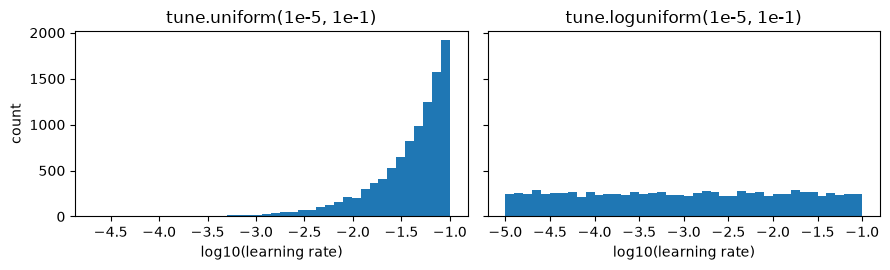

In [8]:
n = 10_000
lr_uniform = np.array(tune.uniform(1e-5, 1e-1).sample(size=n, random_state=SEED))
lr_log = np.array(tune.loguniform(1e-5, 1e-1).sample(size=n, random_state=SEED))
layers = np.array(tune.randint(1, 5).sample(size=n, random_state=SEED))
batch = np.array(tune.choice([32, 64, 128]).sample(size=n, random_state=SEED))

print(f"uniform(1e-5, 1e-1)   : {np.mean(lr_uniform < 1e-3):.1%} of samples below 1e-3")
print(f"loguniform(1e-5, 1e-1): {np.mean(lr_log < 1e-3):.1%} of samples below 1e-3  (2 of the 4 decades)")
print(f"randint(1, 5) values  : {sorted(set(layers.tolist()))}  ← 5 is never sampled")
print(f"choice counts         : {dict(zip(*np.unique(batch, return_counts=True)))}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
for ax, values, title in [(axes[0], lr_uniform, "tune.uniform(1e-5, 1e-1)"), (axes[1], lr_log, "tune.loguniform(1e-5, 1e-1)")]:
    ax.hist(np.log10(values), bins=40)
    ax.set(title=title, xlabel="log10(learning rate)")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

**`grid_search` multiplies.** Grid values are crossed with each other, and the whole grid is repeated `num_samples` times (each repeat re-samples the random dimensions). A trainable that does nothing lets us count trials without training anything:

In [9]:
def noop_trainable(config):
    tune.report({"score": 0.0})


grid_demo = tune.Tuner(
    noop_trainable,
    param_space={"lr": tune.grid_search([1e-3, 1e-2]), "batch_size": tune.grid_search([64, 128, 256]), "dropout": tune.uniform(0, 0.5)},
    tune_config=tune.TuneConfig(num_samples=2),
    run_config=run_config("grid_demo"),
).fit()
grid_df = grid_demo.get_dataframe()
print(f"2 lrs × 3 batch sizes × num_samples=2 → {len(grid_demo)} trials")
print(grid_df[["config/lr", "config/batch_size", "config/dropout"]].sort_values(["config/lr", "config/batch_size"]).round(3).to_string(index=False))

2 lrs × 3 batch sizes × num_samples=2 → 12 trials
 config/lr  config/batch_size  config/dropout
     0.001                 64           0.076
     0.001                 64           0.489
     0.001                128           0.485
     0.001                128           0.229
     0.001                256           0.034
     0.001                256           0.021
     0.010                 64           0.111
     0.010                 64           0.055
     0.010                128           0.481
     0.010                128           0.199
     0.010                256           0.065
     0.010                256           0.080


**Conditional spaces.** `tune.sample_from(lambda spec: ...)` computes a value from other sampled values (e.g. `hidden = 2 ** n_bits`). Model-based searchers such as `OptunaSearch` can't read such lambdas; for them, pass a *define-by-run* function instead (Section 8 notes where).

### ✍️ Your Turn

How many trials does this create? `param_space={"optimizer": tune.grid_search(["adam", "sgd", "adamw"]), "wd": tune.grid_search([0.0, 1e-4]), "lr": tune.loguniform(1e-4, 1e-1)}` with `num_samples=4`. Store the number in `n_trials`.

In [10]:
n_trials = None  # TODO: your code here
check("n_trials", n_trials, 24, hint="(grid combinations) × num_samples; random dimensions don't add trials.")

⏳ n_trials: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_trials = 3 * 2 * 4
check("n_trials", n_trials, 24)
```

3 optimizers × 2 weight decays = 6 grid points, repeated `num_samples=4` times, each repeat with a freshly sampled `lr`. Grid dimensions explode quickly — this is why random search is the default for more than 2–3 hyperparameters.
</details>

> 💡 **Interview angle:** "Why sample learning rates on a log scale?" — useful values span orders of magnitude (1e-5 … 1e-1); a uniform sampler puts ~99% of samples in the top decade, so small learning rates are almost never tried.

## 4. Reporting Metrics Every Epoch and Saving Checkpoints 🟡

A **checkpoint** is a folder with everything needed to continue training: model weights, optimizer state, the epoch number. Checkpoints are what make the advanced features work:

| Feature | Why it needs checkpoints |
|---|---|
| Picking the **best epoch**, not the last | reload the weights from that epoch |
| **Fault tolerance** (Section 10) | a crashed trial restarts from its last checkpoint, not from scratch |
| **HyperBand / PBT** (Sections 6–7) | trials are paused and resumed, or cloned from a better trial |

The pattern: write files into a temporary directory, pass `Checkpoint.from_directory(tmp)` to `tune.report` (Tune copies it into storage), and at the start call `tune.get_checkpoint()` to resume if one exists.

In [11]:
def train_mlp(config, data=None):
    """Production-style trainable: resumable, reports every epoch, checkpoints every epoch."""
    torch.set_num_threads(1)
    X_tr, y_tr, X_va, y_va = (torch.tensor(a) for a in data)
    model, optimizer = build_mlp(config)
    generator = torch.Generator().manual_seed(config.get("seed", SEED))
    start_epoch = 0

    checkpoint = tune.get_checkpoint()                   # set when resuming, retrying, or cloning (PBT)
    if checkpoint:
        with checkpoint.as_directory() as ckpt_dir:
            state = torch.load(Path(ckpt_dir) / "state.pt")
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        start_epoch = state["epoch"]
        for group in optimizer.param_groups:             # the loaded optimizer state carries the OLD lr —
            group["lr"] = config["lr"]                   # use the lr from THIS trial's config (matters for PBT)

    for epoch in range(start_epoch, config["epochs"]):
        train_one_epoch(model, optimizer, X_tr, y_tr, config["batch_size"], generator)
        val_loss, val_acc = evaluate(model, X_va, y_va)
        with tempfile.TemporaryDirectory() as tmp:
            torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": epoch + 1}, Path(tmp) / "state.pt")
            tune.report({"val_loss": val_loss, "val_acc": val_acc, "epoch": epoch + 1, "lr": config["lr"], "resumed_from": start_epoch},
                        checkpoint=Checkpoint.from_directory(tmp))


ckpt_results = tune.Tuner(
    tune.with_parameters(train_mlp, data=DATA),
    param_space={"lr": tune.grid_search([3e-4, 3e-3, 3e-2, 3e-1]), "hidden": 64, "batch_size": 256, "epochs": 8},
    tune_config=tune.TuneConfig(metric="val_acc", mode="max"),
    run_config=run_config("checkpoints", checkpoint_config=tune.CheckpointConfig(
        num_to_keep=2, checkpoint_score_attribute="val_acc", checkpoint_score_order="max")),   # keep the 2 best epochs per trial
).fit()

best_trial = ckpt_results.get_best_result(scope="all")               # best epoch of any trial, not just last epochs
best_ckpt = best_trial.get_best_checkpoint(metric="val_acc", mode="max")
print("best lr:", best_trial.config["lr"])
print("kept checkpoints (epoch → val_acc):", [(m["epoch"], round(m["val_acc"], 4)) for _, m in best_trial.best_checkpoints])
print("best checkpoint folder:", rel(best_ckpt.path))

# Reload the weights and confirm they reproduce the reported validation accuracy
with best_ckpt.as_directory() as ckpt_dir:
    state = torch.load(Path(ckpt_dir) / "state.pt")
reloaded, _ = build_mlp(best_trial.config)
reloaded.load_state_dict(state["model"])
_, reloaded_acc = evaluate(reloaded, torch.tensor(X_val), torch.tensor(y_val))
reported_acc = max(m["val_acc"] for _, m in best_trial.best_checkpoints)
print(f"reported val_acc {reported_acc:.4f} | reloaded model val_acc {reloaded_acc:.4f} (epoch {state['epoch']})")
assert abs(reported_acc - reloaded_acc) < 1e-6

best lr: 0.003
kept checkpoints (epoch → val_acc): [(6, 0.74), (7, 0.7484)]
best checkpoint folder: _outputs/ray_results/checkpoints/train_mlp_66038_00001_1_lr=0.0030_2026-09-13_22-17-13/checkpoint_000006
reported val_acc 0.7484 | reloaded model val_acc 0.7484 (epoch 7)


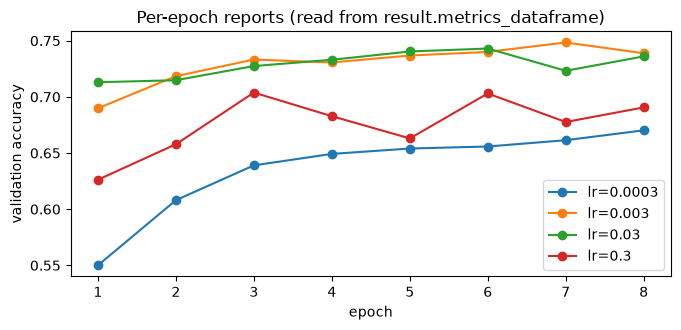

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for result in ckpt_results:
    history = result.metrics_dataframe                                  # every report of this trial
    ax.plot(history["epoch"], history["val_acc"], marker="o", label=f"lr={result.config['lr']:g}")
ax.set(xlabel="epoch", ylabel="validation accuracy", title="Per-epoch reports (read from result.metrics_dataframe)")
ax.legend()
plt.tight_layout()
plt.show()

`num_to_keep=2` with `checkpoint_score_attribute="val_acc"` keeps only the 2 best checkpoints per trial on disk — essential when each checkpoint is a multi-GB model.

> 💡 **Interview angle:** "What goes into a training checkpoint?" — model weights **and** optimizer state (Adam's moment estimates), the epoch/step, LR-scheduler and RNG state if you need exact resumption. Saving only weights silently changes training after a restart.

## 5. ASHA: Early Stopping That Saves Compute 🟡

Most configs are obviously bad after a few epochs. **Successive halving (SH)** exploits that:

1. Start many configs with a **small budget** (e.g. 1 epoch).
2. Keep only the best **1/η** of them (η = `reduction_factor`, e.g. 3) and give them **η× more budget**.
3. Repeat until the survivors reach the maximum budget.

The budget checkpoints are called **rungs**. With `grace_period=1`, `reduction_factor=3`, `max_t=9` the rungs are at epochs **1 → 3 → 9**:

```
 epoch 1 rung:  ■■■■■■■■■■■■■■■■■■  18 trials   keep top 1/3 → 6
 epoch 3 rung:  ■■■■■■                6 trials   keep top 1/3 → 2
 epoch 9 (max): ■■                    2 trials finish
```

Plain SH waits until **all** trials reach a rung before comparing them — workers sit idle. **ASHA** (Asynchronous Successive Halving, Li et al. 2020) decides **the moment a trial reaches a rung**: it continues only if its score is in the top 1/η of all scores recorded at that rung *so far*. No waiting, so it scales to hundreds of workers. The price: early trials are judged against fewer competitors.

| `ASHAScheduler` argument | Meaning |
|---|---|
| `time_attr` | the clock — default `training_iteration` (number of `tune.report` calls) |
| `max_t` | maximum budget per trial (epochs here) |
| `grace_period` | minimum budget before a trial can be stopped (first rung) |
| `reduction_factor` | η: keep top 1/η per rung, rungs spaced η× apart |

**A fair measurement.** We run the **same 18 configs** twice: once with the default **FIFO** scheduler (every trial trains all 9 epochs) and once with ASHA. FIFO tells us the *true* final accuracy of every config, so we can check whether ASHA stopped the right ones.

In [13]:
MAX_EPOCHS = 9
pool_rng = np.random.default_rng(1)
POOL18 = [{"pool_id": i, "lr": float(10 ** pool_rng.uniform(-4.5, -0.5)), "hidden": int(pool_rng.choice([16, 64, 256])),
           "batch_size": int(pool_rng.choice([128, 512]))} for i in range(18)]
pool_space = {"pool_id": tune.randint(0, 18), "lr": tune.loguniform(10 ** -4.5, 10 ** -0.5), "hidden": tune.choice([16, 64, 256]),
              "batch_size": tune.choice([128, 512]), "epochs": MAX_EPOCHS}


def run_pool(name, scheduler=None):
    """Train the 18 fixed configs under a given scheduler; return results, per-trial dataframe, wall seconds."""
    start = time.perf_counter()
    results = tune.Tuner(
        tune.with_parameters(train_mlp, data=DATA),
        param_space=pool_space,
        tune_config=tune.TuneConfig(metric="val_acc", mode="max", num_samples=len(POOL18), scheduler=scheduler,
                                    search_alg=BasicVariantGenerator(points_to_evaluate=POOL18)),
        run_config=run_config(name, checkpoint_config=tune.CheckpointConfig(num_to_keep=1)),
    ).fit()
    seconds = time.perf_counter() - start
    assert results.num_errors == 0
    return results, results.get_dataframe().set_index("config/pool_id").sort_index(), seconds


fifo_results, fifo_df, fifo_seconds = run_pool("pool_fifo")                       # FIFO = no early stopping
asha = ASHAScheduler(max_t=MAX_EPOCHS, grace_period=1, reduction_factor=3)       # metric & mode come from TuneConfig
asha_results, asha_df, asha_seconds = run_pool("pool_asha", asha)
print("ASHA rung milestones:", sorted(m for m, _ in asha._brackets[0]._rungs))

true_final = fifo_df["val_acc"]                                                   # accuracy of each config after 9 epochs
asha_pick = asha_results.get_best_result().config["pool_id"]
fifo_pick = int(true_final.idxmax())
regret = true_final.max() - true_final[asha_pick]
rank = int((true_final > true_final[asha_pick]).sum()) + 1

pool_summary = pd.DataFrame([
    {"scheduler": "FIFO", "epochs trained": int(fifo_df["training_iteration"].sum()), "wall seconds": round(fifo_seconds, 1),
     "trials run to max_t": int((fifo_df["training_iteration"] == MAX_EPOCHS).sum()), "picked config": fifo_pick},
    {"scheduler": "ASHA", "epochs trained": int(asha_df["training_iteration"].sum()), "wall seconds": round(asha_seconds, 1),
     "trials run to max_t": int((asha_df["training_iteration"] == MAX_EPOCHS).sum()), "picked config": asha_pick},
]).set_index("scheduler")
print(pool_summary.to_string())

compute_ratio = pool_summary.loc["ASHA", "epochs trained"] / pool_summary.loc["FIFO", "epochs trained"]
print(f"\nASHA used {compute_ratio:.0%} of FIFO's epochs and {asha_seconds / fifo_seconds:.0%} of its wall time.")
print(f"ASHA's pick (config {asha_pick}) ranks #{rank} of 18 by true 9-epoch accuracy; "
      f"regret = {regret:.4f} ({true_final[asha_pick]:.4f} vs best {true_final.max():.4f}).")

ASHA rung milestones: [1, 3, 9]
           epochs trained  wall seconds  trials run to max_t  picked config
scheduler                                                                  
FIFO                  162          20.1                   18              5
ASHA                   60          19.7                    5             13

ASHA used 37% of FIFO's epochs and 98% of its wall time.
ASHA's pick (config 13) ranks #2 of 18 by true 9-epoch accuracy; regret = 0.0040 (0.7626 vs best 0.7666).


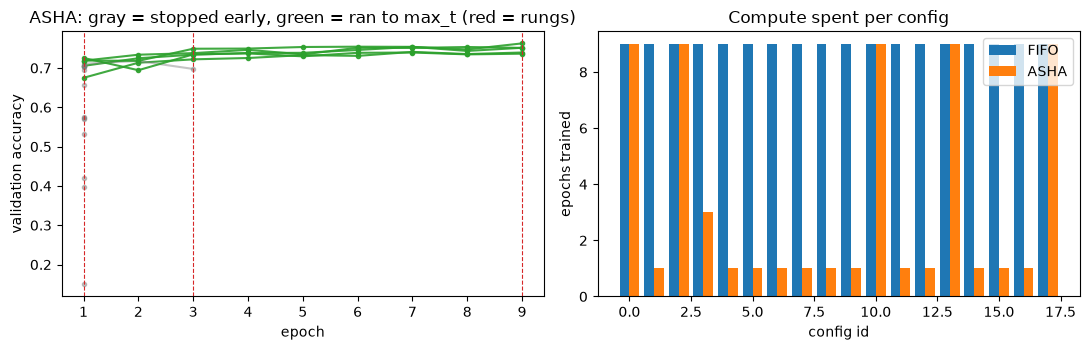

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for result in asha_results:
    hist = result.metrics_dataframe
    finished = len(hist) == MAX_EPOCHS
    axes[0].plot(hist["epoch"], hist["val_acc"], marker="o", ms=3, alpha=0.9 if finished else 0.45,
                 color="tab:green" if finished else "tab:gray")
for milestone in (1, 3, 9):
    axes[0].axvline(milestone, ls="--", c="tab:red", lw=0.8)
axes[0].set(xlabel="epoch", ylabel="validation accuracy", title="ASHA: gray = stopped early, green = ran to max_t (red = rungs)")

ids = np.arange(len(POOL18))
axes[1].bar(ids - 0.2, fifo_df["training_iteration"], width=0.4, label="FIFO")
axes[1].bar(ids + 0.2, asha_df["training_iteration"], width=0.4, label="ASHA")
axes[1].set(xlabel="config id", ylabel="epochs trained", title="Compute spent per config")
axes[1].legend()
plt.tight_layout()
plt.show()

Two honest caveats you should mention in an interview:
- ASHA's decisions depend on **arrival order** (it's asynchronous), so re-running can stop slightly different trials.
- Wall time saves less than epochs: every trial still pays its start-up cost, and with only 4 workers the cheap early rungs dominate.

### ✍️ Your Turn

From `fifo_df` and `asha_df`, compute the **fraction of epochs ASHA saved** compared with FIFO (e.g. `0.7` means 70% fewer epochs). Store it in `epochs_saved`.

In [15]:
epochs_saved = None  # TODO: your code here
check("epochs_saved", epochs_saved, 1 - asha_df["training_iteration"].sum() / fifo_df["training_iteration"].sum(),
      hint="1 - (total ASHA training_iteration) / (total FIFO training_iteration)")

⏳ epochs_saved: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
epochs_saved = 1 - asha_df["training_iteration"].sum() / fifo_df["training_iteration"].sum()
check("epochs_saved", epochs_saved, 1 - asha_df["training_iteration"].sum() / fifo_df["training_iteration"].sum())
```

`training_iteration` is the number of reports, i.e. epochs here. Summing it over trials gives the total compute each scheduler spent.
</details>

> 💡 **Interview angle:** "How does ASHA work and what does it cost?" — rungs at `grace_period × η^k`; at each rung a trial continues only if it's in the top 1/η of results recorded there so far, decided asynchronously. It does **not** cost "about one trial": with n configs it spends roughly n·grace epochs per rung level plus the survivors' full runs — measured here as a fraction of FIFO, not a constant.

## 6. HyperBand: Hedging the Early-Stopping Bet 🟡

Successive halving has one knob you must guess: **how early to judge**. Judge after 1 epoch and you may kill a *late bloomer* (e.g. a small learning rate that starts slow but finishes best). Judge late and you save little.

**HyperBand** (Li et al. 2018) doesn't guess — it runs several SH **brackets** that make different trade-offs, from "many configs, judged very early" to "few configs, no early stopping":

| Bracket (max budget 9, η = 3) | Configs started | First judged at epoch |
|---|---|---|
| most aggressive | 9 | 1 |
| middle | 5 | 3 |
| no early stopping | 3 | 9 |

In Ray, `HyperBandScheduler` is the **synchronous** version: trials are **paused** at a rung (checkpoint saved) until their bracket-mates catch up, then the best are **resumed** from their checkpoints. That's why it needs a resumable trainable. For the asynchronous flavour, use `ASHAScheduler(brackets=3)`.

Same 18 configs again:

In [16]:
hyperband_results, hyperband_df, hyperband_seconds = run_pool("pool_hyperband", HyperBandScheduler(max_t=MAX_EPOCHS, reduction_factor=3))
hb_pick = hyperband_results.get_best_result().config["pool_id"]
hb_resumed = int(sum(r.metrics_dataframe["resumed_from"].gt(0).any() for r in hyperband_results))

pool_summary.loc["HyperBand"] = {"epochs trained": int(hyperband_df["training_iteration"].sum()), "wall seconds": round(hyperband_seconds, 1),
                                 "trials run to max_t": int((hyperband_df["training_iteration"] == MAX_EPOCHS).sum()), "picked config": hb_pick}
pool_summary["regret (true acc gap)"] = [round(float(true_final.max() - true_final[p]), 4) for p in pool_summary["picked config"]]
print(pool_summary.to_string())
print(f"\n{hb_resumed} HyperBand trials were paused and later resumed from a checkpoint.")
cheapest = pool_summary["epochs trained"].idxmin()
fastest = pool_summary["wall seconds"].idxmin()
print(f"fewest epochs: {cheapest} | fastest wall clock: {fastest}")
if pool_summary.loc["HyperBand", "wall seconds"] > pool_summary.loc["ASHA", "wall seconds"]:
    print("HyperBand was slower than ASHA here: pausing/resuming costs checkpoint I/O and idle workers while brackets synchronise.")

           epochs trained  wall seconds  trials run to max_t  picked config  regret (true acc gap)
scheduler                                                                                         
FIFO                  162          20.1                   18              5                 0.0000
ASHA                   60          19.7                    5             13                 0.0040
HyperBand              84          28.7                    7              0                 0.0152

5 HyperBand trials were paused and later resumed from a checkpoint.
fewest epochs: ASHA | fastest wall clock: ASHA
HyperBand was slower than ASHA here: pausing/resuming costs checkpoint I/O and idle workers while brackets synchronise.


> 💡 **Interview angle:** "ASHA or HyperBand?" — HyperBand hedges against a badly chosen grace period by running brackets with different early-stopping aggressiveness; ASHA is the asynchronous, easier-to-scale form of one bracket (and Ray's `ASHAScheduler(brackets>1)` adds the hedge back). In practice ASHA is the default for large parallel jobs.

## 7. Population Based Training 🔴

Every method so far picks **one fixed config** per trial. But good hyperparameters change *during* training — a higher learning rate early, a lower one later. **Population Based Training (PBT)** (Jaderberg et al. 2017, DeepMind) trains a population of trials in parallel and periodically:

1. **Exploit** — a trial in the bottom `quantile_fraction` **copies the checkpoint** (weights + optimizer) of a trial in the top quantile.
2. **Explore** — it then **mutates** the copied hyperparameters: multiply by 0.8 or 1.2 (`perturbation_factors`), or, with probability `resample_probability`, draw a fresh value from `hyperparam_mutations`.

```
 epoch:   0 ─── 3 ─── 6 ─── 9 ─── 12
 trial A: ████ ████ ████ ████           (top — keeps going)
 trial D: ████ ↘ copy A's weights, lr×1.2 → ████ ████
```

The result is a **schedule** of hyperparameters plus a trained model — not a single config you can re-run from scratch. PBT is only possible with checkpoints, and costs no extra compute over training the population normally.

**Experiment:** 4 trials starting from deliberately poor learning rates (two too small, two too large), 12 epochs each. **Fixed** = FIFO with the same 4 starting lrs; **PBT** = same starts, exploit/explore every 3 epochs.

In [17]:
PBT_START_LRS = [1e-5, 3e-5, 0.3, 1.0]
pbt_space = {"lr": tune.grid_search(PBT_START_LRS), "hidden": 64, "batch_size": 256, "epochs": 12}

fixed_lr_results = tune.Tuner(tune.with_parameters(train_mlp, data=DATA), param_space=pbt_space,
                              tune_config=tune.TuneConfig(metric="val_acc", mode="max"),
                              run_config=run_config("pbt_fixed_baseline", checkpoint_config=tune.CheckpointConfig(num_to_keep=1))).fit()

pbt_scheduler = PopulationBasedTraining(
    time_attr="training_iteration",
    perturbation_interval=3,                             # exploit/explore every 3 epochs
    quantile_fraction=0.25,                              # bottom 25% copy from top 25% (1 of 4 trials each)
    resample_probability=0.25,
    hyperparam_mutations={"lr": tune.loguniform(1e-5, 1.0)},
)
pbt_results = tune.Tuner(tune.with_parameters(train_mlp, data=DATA), param_space=pbt_space,
                         tune_config=tune.TuneConfig(metric="val_acc", mode="max", scheduler=pbt_scheduler,
                                                     reuse_actors=True),          # reuse worker processes between clones
                         run_config=run_config("pbt")).fit()               # keep ALL checkpoints — see note below
assert fixed_lr_results.num_errors == 0 and pbt_results.num_errors == 0

fixed_best = fixed_lr_results.get_best_result().metrics["val_acc"]
pbt_best = pbt_results.get_best_result().metrics["val_acc"]
fixed_epochs = int(fixed_lr_results.get_dataframe()["training_iteration"].sum())
pbt_reports = sum(len(r.metrics_dataframe) for r in pbt_results)
print(f"fixed learning rates: best final val_acc {fixed_best:.4f} ({fixed_epochs} epochs trained)")
print(f"PBT                 : best final val_acc {pbt_best:.4f} ({pbt_reports} epoch reports)")
for result in pbt_results:
    lr_path = result.metrics_dataframe["lr"].to_numpy()
    changes = int((np.diff(lr_path) != 0).sum())
    print(f"  PBT trial started lr={lr_path[0]:.0e} → final lr={lr_path[-1]:.2e} after {changes} exploit/explore steps, final val_acc {result.metrics['val_acc']:.4f}")
print("→ PBT beat the fixed schedules" if pbt_best > fixed_best else "→ PBT did not beat the best fixed schedule on this run")

fixed learning rates: best final val_acc 0.6666 (48 epochs trained)
PBT                 : best final val_acc 0.7064 (54 epoch reports)
  PBT trial started lr=1e-05 → final lr=2.40e-01 after 2 exploit/explore steps, final val_acc 0.7064
  PBT trial started lr=3e-05 → final lr=3.00e-05 after 0 exploit/explore steps, final val_acc 0.5728
  PBT trial started lr=3e-01 → final lr=3.00e-01 after 0 exploit/explore steps, final val_acc 0.6152
  PBT trial started lr=1e+00 → final lr=1.00e+00 after 0 exploit/explore steps, final val_acc 0.4908
→ PBT beat the fixed schedules


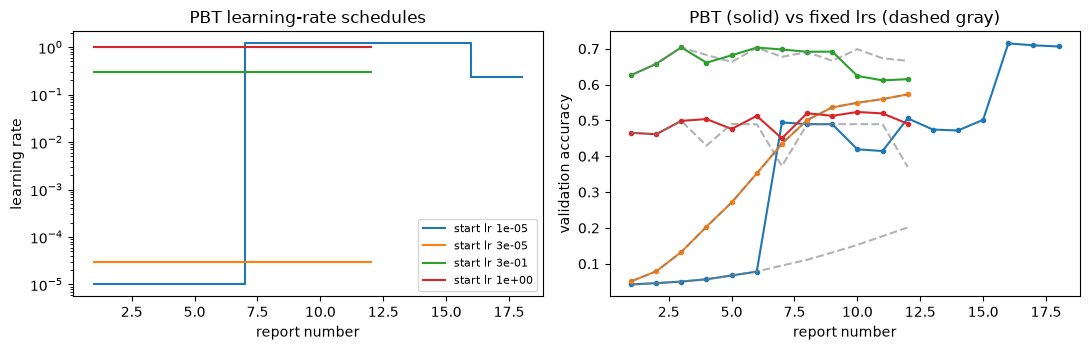

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for result in pbt_results:
    hist = result.metrics_dataframe
    steps = np.arange(1, len(hist) + 1)
    axes[0].step(steps, hist["lr"], where="post", label=f"start lr {hist['lr'].iloc[0]:.0e}")
    axes[1].plot(steps, hist["val_acc"], marker="o", ms=3)
for result in fixed_lr_results:
    axes[1].plot(result.metrics_dataframe["epoch"], result.metrics_dataframe["val_acc"], ls="--", c="gray", alpha=0.6)
axes[0].set(yscale="log", xlabel="report number", ylabel="learning rate", title="PBT learning-rate schedules")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="report number", ylabel="validation accuracy", title="PBT (solid) vs fixed lrs (dashed gray)")
plt.tight_layout()
plt.show()

PBT is non-deterministic (random exploit partners and mutations), so the exact curves change between runs. Two implementation details make or break it:
- The trainable **must** restore from `tune.get_checkpoint()` — that's how the clone receives the donor's weights.
- After loading the optimizer state, **re-apply `config["lr"]`**. `optimizer.load_state_dict` restores the *donor's old* learning rate, silently undoing the exploration step (Pitfall 2 demonstrates this).
- **Don't set a small `CheckpointConfig(num_to_keep=...)` with PBT.** While writing this notebook, `num_to_keep=2` made trials fail with *"Could not recover from checkpoint as it does not exist on storage anymore"*: the donor had already deleted the checkpoint the clone was about to load. Keep more checkpoints (or all, as here) and clean up after the experiment.

> 💡 **Interview angle:** "Explain PBT." — a population trains in parallel; periodically the worst members copy the weights of the best (exploit) and perturb their hyperparameters (explore), yielding a hyperparameter *schedule* at no extra compute. Needs checkpointing; common for RL and long DL runs; the final model isn't reproducible from one config unless you replay the schedule.

## 8. Search Algorithms: OptunaSearch on a Gradient-Boosting Model 🟡

Two different jobs — don't mix them up:

| | **Search algorithm** (`search_alg`) | **Scheduler** (`scheduler`) |
|---|---|---|
| Decides | *which configs* to try next | *how long* each trial runs |
| Examples | random/grid (`BasicVariantGenerator`), `OptunaSearch` (TPE), HyperOpt, BOHB | FIFO, ASHA, HyperBand, PBT |
| Learns from | finished (or reported) trial scores | intermediate reports |

They combine: **OptunaSearch + ASHA** = smart proposals *and* early stopping.

**Why limit concurrency?** TPE (Tree-structured Parzen Estimator — the Optuna sampler from the previous notebook) proposes a config based on results *so far*. If 16 trials start at once, all 16 are proposed with **zero** information — that's just random search. `ConcurrencyLimiter(searcher, max_concurrent=4)` makes the searcher wait for results before proposing more. Rule of thumb: keep concurrency well below the total number of trials.

**Tuning gradient boosting.** Boosting rounds play the role of epochs: a LightGBM callback reports the validation log-loss **every 10 rounds**, so ASHA can stop weak configs early. (Ray also ships `ray.tune.integration.lightgbm.TuneReportCheckpointCallback` and an XGBoost equivalent; they report every round, which adds overhead for fast models.)

In [19]:
LGB_ROUNDS, REPORT_EVERY = 200, 10


def lgb_params(config):
    return {"objective": "multiclass", "num_class": N_CLASSES, "metric": "multi_logloss", "verbosity": -1,
            "num_threads": 1, "seed": SEED, "learning_rate": config["learning_rate"], "num_leaves": config["num_leaves"],
            "min_child_samples": config["min_child_samples"], "feature_fraction": config["feature_fraction"],
            "lambda_l2": config["lambda_l2"]}


def train_lgb(config, data=None):
    X_tr, y_tr, X_va, y_va = data
    train_set = lgb.Dataset(X_tr, y_tr)
    val_set = lgb.Dataset(X_va, y_va, reference=train_set)

    def report_to_tune(env):                          # LightGBM calls this after every boosting round
        rounds = env.iteration + 1
        if rounds % REPORT_EVERY == 0:
            _, _, logloss, _ = env.evaluation_result_list[0]
            tune.report({"val_logloss": logloss, "rounds": rounds})

    lgb.train(lgb_params(config), train_set, num_boost_round=LGB_ROUNDS, valid_sets=[val_set], valid_names=["val"],
              callbacks=[report_to_tune])


lgb_space = {"learning_rate": tune.loguniform(0.02, 0.3), "num_leaves": tune.lograndint(8, 256),
             "min_child_samples": tune.randint(5, 100), "feature_fraction": tune.uniform(0.5, 1.0),
             "lambda_l2": tune.loguniform(1e-3, 10.0)}

start = time.perf_counter()
lgb_results = tune.Tuner(
    tune.with_parameters(train_lgb, data=DATA),
    param_space=lgb_space,
    tune_config=tune.TuneConfig(
        metric="val_logloss", mode="min", num_samples=16,
        search_alg=ConcurrencyLimiter(OptunaSearch(seed=SEED), max_concurrent=4),
        scheduler=ASHAScheduler(max_t=LGB_ROUNDS // REPORT_EVERY, grace_period=2, reduction_factor=3),
    ),
    run_config=run_config("lightgbm_optuna_asha"),
).fit()
lgb_seconds = time.perf_counter() - start
lgb_df = lgb_results.get_dataframe()
lgb_best = lgb_results.get_best_result(scope="all")
print(f"16 trials in {lgb_seconds:.1f} s, {int(lgb_df['rounds'].sum())} boosting rounds of {16 * LGB_ROUNDS} possible, errors: {lgb_results.num_errors}")
print("best config:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in lgb_best.config.items()})
best_row = lgb_best.metrics_dataframe.loc[lgb_best.metrics_dataframe["val_logloss"].idxmin()]
print(f"best val_logloss {best_row['val_logloss']:.4f} at {int(best_row['rounds'])} rounds")

16 trials in 18.8 s, 1280 boosting rounds of 3200 possible, errors: 0
best config: {'learning_rate': 0.0896, 'num_leaves': 61, 'min_child_samples': 51, 'feature_fraction': 0.9757, 'lambda_l2': 0.5386}
best val_logloss 0.4127 at 180 rounds


retrained model val_logloss 0.4127 | val accuracy 0.8360


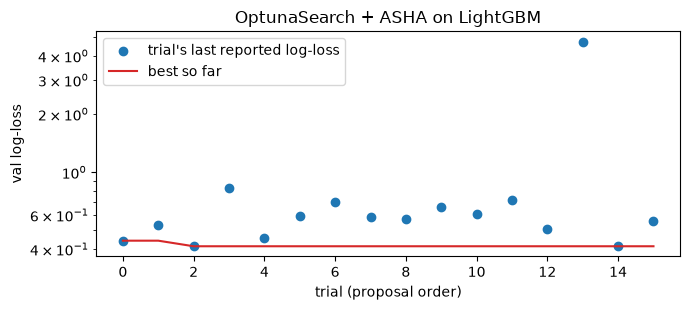

In [20]:
# Retrain the winner in this process for exactly that many rounds — same seed and threads → same model
winner = lgb.train(lgb_params(lgb_best.config), lgb.Dataset(X_train, y_train), num_boost_round=int(best_row["rounds"]))
proba = winner.predict(X_val)
retrained_logloss = -np.mean(np.log(proba[np.arange(len(y_val)), y_val]))
print(f"retrained model val_logloss {retrained_logloss:.4f} | val accuracy {np.mean(proba.argmax(axis=1) == y_val):.4f}")
assert abs(retrained_logloss - best_row["val_logloss"]) < 1e-4

order = lgb_df.sort_values("trial_id")                                  # trial ids increase in proposal order
running_best = order.groupby("trial_id")["val_logloss"].min().cummin()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(range(len(order)), order["val_logloss"], label="trial's last reported log-loss")
ax.plot(range(len(running_best)), running_best.to_numpy(), c="tab:red", label="best so far")
ax.set(xlabel="trial (proposal order)", ylabel="val log-loss", title="OptunaSearch + ASHA on LightGBM", yscale="log")
ax.legend()
plt.tight_layout()
plt.show()

Stopped trials report a higher (worse) log-loss simply because they trained fewer rounds — their scatter points are not comparable with finished ones. That is also why `get_best_result(scope="all")` looks at every report of every trial.

If your space has conditional parameters, give `OptunaSearch(space=define_by_run_fn, metric=..., mode=...)` a function that calls `trial.suggest_*` exactly like in plain Optuna, instead of a `param_space` dict.

### ✍️ Your Turn

How many **boosting rounds** did the trial with the best final log-loss (`lgb_results.get_best_result()`, default `scope="last"`) train before it finished or was stopped? Store it in `best_trial_rounds`.

In [21]:
best_trial_rounds = None  # TODO: your code here
check("best_trial_rounds", best_trial_rounds, lgb_results.get_best_result().metrics_dataframe["rounds"].max(),
      hint="Each report is 10 rounds: look at result.metrics['rounds'] (or training_iteration × 10).")

⏳ best_trial_rounds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_trial_rounds = lgb_results.get_best_result().metrics["rounds"]
check("best_trial_rounds", best_trial_rounds, lgb_results.get_best_result().metrics_dataframe["rounds"].max())
```

`result.metrics` is the **last** report of the trial; `result.metrics_dataframe` holds all of them.
</details>

> 💡 **Interview angle:** "Search algorithm vs scheduler?" — the searcher chooses configs (random, TPE, BOHB), the scheduler allocates training budget (ASHA stops, PBT clones). "Why a concurrency limit with Bayesian search?" — each proposal should use as many finished results as possible; unlimited parallelism degrades TPE to random search.

## 9. Resources per Trial: CPUs, GPUs, and Fractions 🟡

By default each trial reserves **1 CPU**. `tune.with_resources` changes that:

```python
tune.with_resources(trainable, {"cpu": 2})              # 2 CPUs per trial → at most 2 trials on 4 CPUs
tune.with_resources(trainable, {"cpu": 1, "gpu": 0.25})  # 4 trials share one GPU
tune.TuneConfig(max_concurrent_trials=3)                 # an extra cap, independent of resources
```

Resources are **bookkeeping, not isolation**: Ray only counts them to decide how many trials fit. `{"gpu": 0.25}` does *not* limit a trial to a quarter of GPU memory — you must pick a batch size that fits. What Ray *does* set inside each trial is `CUDA_VISIBLE_DEVICES` (which GPU it may see) and `OMP_NUM_THREADS` (how many threads math libraries like PyTorch/NumPy should use). Let's measure both the concurrency and the thread setting with a trainable that just sleeps:

In [22]:
def probe_trainable(config):
    started = time.time()
    time.sleep(3)                                          # pretend to train
    tune.report({"omp_num_threads": int(os.environ.get("OMP_NUM_THREADS", "0")), "torch_threads": torch.get_num_threads(),
                 "start": started, "end": time.time()})


def max_overlap(df):
    """Largest number of trials that were running at the same moment."""
    events = sorted([(t, 1) for t in df["start"]] + [(t, -1) for t in df["end"]])
    running = peak = 0
    for _, change in events:
        running += change
        peak = max(peak, running)
    return peak


resource_rows = []
for cpus in [1, 0.5, 2]:
    start = time.perf_counter()
    probe = tune.Tuner(tune.with_resources(probe_trainable, {"cpu": cpus}), param_space={"i": tune.grid_search(list(range(8)))},
                       run_config=run_config(f"resources_cpu_{cpus}")).fit()
    probe_df = probe.get_dataframe()
    resource_rows.append({"cpu per trial": cpus, "expected max concurrent": int(4 // cpus), "measured max concurrent": max_overlap(probe_df),
                          "OMP_NUM_THREADS in trial": sorted(probe_df["omp_num_threads"].unique().tolist()),
                          "torch threads in trial": sorted(probe_df["torch_threads"].unique().tolist()),
                          "wall seconds (8 trials × 3 s)": round(time.perf_counter() - start, 1)})
print(pd.DataFrame(resource_rows).to_string(index=False))

n_gpus = ray.cluster_resources().get("GPU", 0)
if n_gpus == 0:
    print("\n⏭️ No GPU registered with Ray here, so trials requesting {'gpu': ...} would wait forever. "
          "On a CUDA machine or Colab, tune.with_resources(trainable, {'cpu': 1, 'gpu': 0.25}) runs 4 trials per GPU.")
else:
    print(f"\nRay registered {n_gpus:g} GPU(s): tune.with_resources(trainable, {{'cpu': 1, 'gpu': 0.25}}) would pack 4 trials per GPU. "
          "We don't request it — these tiny MLPs are faster on CPU, and the trial code would also have to move tensors to that device.")

 cpu per trial  expected max concurrent  measured max concurrent OMP_NUM_THREADS in trial torch threads in trial  wall seconds (8 trials × 3 s)
           1.0                        4                        4                      [1]                    [1]                           12.6
           0.5                        8                        8                      [1]                    [1]                            7.8
           2.0                        2                        2                      [2]                    [2]                           24.1

Ray registered 1 GPU(s): tune.with_resources(trainable, {'cpu': 1, 'gpu': 0.25}) would pack 4 trials per GPU. We don't request it — these tiny MLPs are faster on CPU, and the trial code would also have to move tensors to that device.


Notice that a 0.5-CPU trial still gets `OMP_NUM_THREADS=1` (it can't be less than one thread), and two trials now share each CPU. Fractional CPUs make sense for **I/O-bound** trials (waiting on a remote API or a GPU); for CPU-heavy training they just oversubscribe the machine.

### ✍️ Your Turn

A Ray cluster has **4 CPUs** and each trial requests `{"cpu": 1.5}`. How many trials can run at the same time? Store it in `concurrent_trials`.

In [23]:
concurrent_trials = None  # TODO: your code here
check("concurrent_trials", concurrent_trials, 2, hint="Ray only starts a trial when all its requested resources are free: floor(4 / 1.5).")

⏳ concurrent_trials: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
concurrent_trials = int(4 // 1.5)
check("concurrent_trials", concurrent_trials, 2)
```

Two trials use 3 CPUs; the remaining 1 CPU is not enough for a third. Choosing `{"cpu": 2}` would give the same concurrency with more threads per trial.
</details>

> 💡 **Interview angle:** "Parallel tuning made every trial slower — why?" — CPU **oversubscription**: 4 trials each starting 16 threads (`n_jobs=-1`, default BLAS pools) fight over 16 cores. Match threads to the resources a trial requested (Ray sets `OMP_NUM_THREADS` for you; libraries with their own `n_jobs` still need it set), and remember fractional GPUs don't split memory.

## 10. Fault Tolerance and Resuming Experiments 🟡

Long experiments meet crashes: spot instances get preempted, a node runs out of memory, someone closes the laptop. Ray Tune has two layers of protection:

| Problem | Tool | What happens |
|---|---|---|
| one **trial** crashes | `RunConfig(failure_config=tune.FailureConfig(max_failures=2))` | the trial is restarted (up to 2 times) **from its latest checkpoint** |
| the whole **experiment/driver** stops | `tune.Tuner.restore(path, trainable, resume_errored=True)` | reloads the experiment state from `storage_path`, skips finished trials, resumes unfinished/errored ones from checkpoints |

On a multi-node cluster, `storage_path` must be **shared** storage (`s3://…`, `gs://…`, or NFS) so any node can read the checkpoints.

To trigger a failure on purpose without editing `train_mlp`, we wrap `tune.report` so the worker raises an exception right after reporting epoch 4 — but only the first time (a marker file remembers that the crash already happened).

In [24]:
def train_mlp_flaky(config, data=None, marker=None):
    """train_mlp, but the worker crashes once, right after reporting epoch 4 (a deliberate, controlled failure)."""
    real_report = tune.report

    def report_then_crash_once(metrics, checkpoint=None):
        real_report(metrics, checkpoint=checkpoint)
        if metrics["epoch"] == 4 and not Path(marker).exists():
            Path(marker).touch()
            raise RuntimeError("deliberate worker crash after epoch 4")

    tune.report = report_then_crash_once
    try:
        train_mlp(config, data)
    finally:
        tune.report = real_report


retry_marker = STORAGE / "crash_marker_retry"
with quiet_expected_failures():
    retry_results = tune.Tuner(
        tune.with_parameters(train_mlp_flaky, data=DATA, marker=str(retry_marker)),
        param_space={"lr": 3e-3, "hidden": 64, "batch_size": 256, "epochs": 8},
        run_config=run_config("fault_retry", failure_config=tune.FailureConfig(max_failures=2)),
    ).fit()

retry_history = retry_results[0].metrics_dataframe
print(f"crash happened: {retry_marker.exists()} | errors after retries: {retry_results.num_errors}")
print("epoch each report came from    :", retry_history["epoch"].tolist())
print("epoch the attempt resumed from :", retry_history["resumed_from"].tolist())
assert retry_results.num_errors == 0 and retry_history["resumed_from"].iloc[-1] == 4

crash happened: True | errors after retries: 0
epoch each report came from    : [1, 2, 3, 4, 5, 6, 7, 8]
epoch the attempt resumed from : [0, 0, 0, 0, 4, 4, 4, 4]


The trial crashed after epoch 4, Tune restarted it, and `tune.get_checkpoint()` handed it the epoch-4 checkpoint — epochs 1–4 were **not** recomputed.

Now the second layer. With the default `max_failures=0`, a crash marks the trial as **errored** and the experiment finishes without it. Later (in a new process, even on another machine) we restore the experiment from its folder and resume only what's missing:

In [25]:
resume_marker = STORAGE / "crash_marker_resume"
resume_space = {"lr": tune.grid_search([1e-3, 3e-3, 1e-2]), "hidden": 64, "batch_size": 256, "epochs": 8}
flaky = tune.with_parameters(train_mlp_flaky, data=DATA, marker=str(resume_marker))

with quiet_expected_failures():
    first_attempt = tune.Tuner(flaky, param_space=resume_space, tune_config=tune.TuneConfig(metric="val_acc", mode="max"),
                               run_config=run_config("fault_resume")).fit()
errored = [r for r in first_attempt if r.error is not None]
print(f"first attempt: {len(first_attempt)} trials, {first_attempt.num_errors} errored")
for r in errored:
    cause = getattr(r.error, "cause", r.error)
    print(f"  lr={r.config['lr']}: {type(cause).__name__}: {cause} (stopped at epoch {int(r.metrics['epoch'])})")

experiment_path = STORAGE / "fault_resume"
print("can restore:", tune.Tuner.can_restore(str(experiment_path)), "| path:", rel(experiment_path))

first attempt: 3 trials, 1 errored
  lr=0.003: RuntimeError: deliberate worker crash after epoch 4 (stopped at epoch 4)
can restore: True | path: _outputs/ray_results/fault_resume


In [26]:
with quiet_expected_failures():
    resumed = tune.Tuner.restore(str(experiment_path), trainable=flaky, resume_errored=True).fit()
print(f"after restore: {len(resumed)} trials, {resumed.num_errors} errored")
for r in resumed:
    history = r.metrics_dataframe
    print(f"  lr={r.config['lr']}: final epoch {int(r.metrics['epoch'])}, val_acc {r.metrics['val_acc']:.4f}, "
          f"last attempt resumed from epoch {int(history['resumed_from'].iloc[-1])}")
assert resumed.num_errors == 0

after restore: 3 trials, 0 errored
  lr=0.001: final epoch 8, val_acc 0.7266, last attempt resumed from epoch 0
  lr=0.01: final epoch 8, val_acc 0.7400, last attempt resumed from epoch 0
  lr=0.003: final epoch 8, val_acc 0.7496, last attempt resumed from epoch 4


`resume_errored=True` continues errored trials from their last checkpoint; `restart_errored=True` would start them from scratch; unfinished trials (e.g. after Ctrl+C) resume by default.

> 💡 **Interview angle:** "A 3-day tuning job dies on day 2 — what did you set up beforehand?" — per-epoch checkpoints with model **and** optimizer state, `FailureConfig(max_failures=k)` for transient trial failures, experiment state on durable shared storage, and `Tuner.restore(..., resume_errored=True)` to continue; plus `num_to_keep` so checkpoints don't fill the disk.

## 11. Analysing Results 🟢

A `ResultGrid` gives you everything Tune recorded:

| Call | Returns |
|---|---|
| `results.get_dataframe()` | one row per trial — its **last** report + `config/*` columns |
| `results.get_dataframe(filter_metric="val_acc", filter_mode="max")` | one row per trial — its **best** report |
| `results.get_best_result(scope="last" / "all")` | best trial judged by last report / by any report |
| `result.metrics_dataframe` | every report of one trial (learning curve) |
| `result.config`, `result.checkpoint`, `result.get_best_checkpoint(...)` | config and checkpoints of one trial |
| `tune.Tuner.restore(path, trainable).get_results()` | the same `ResultGrid`, reloaded from disk later |

In [27]:
last_df = fifo_results.get_dataframe().set_index("config/pool_id").sort_index()
best_epoch_df = fifo_results.get_dataframe(filter_metric="val_acc", filter_mode="max").set_index("config/pool_id").sort_index()
analysis = pd.DataFrame({"lr": last_df["config/lr"], "hidden": last_df["config/hidden"], "batch": last_df["config/batch_size"],
                         "last val_acc": last_df["val_acc"], "best val_acc": best_epoch_df["val_acc"],
                         "best epoch": best_epoch_df["epoch"].astype(int)})
print(analysis.sort_values("best val_acc", ascending=False).round(4).head(8).to_string())

by_last = fifo_results.get_best_result(scope="last")
by_all = fifo_results.get_best_result(scope="all")
print(f"\nbest by last epoch: config {by_last.config['pool_id']} ({by_last.metrics['val_acc']:.4f}) | "
      f"best by any epoch: config {by_all.config['pool_id']} (best report {by_all.metrics_dataframe['val_acc'].max():.4f})")

# Results live on disk: reload them as if in a new session
reloaded_grid = tune.Tuner.restore(str(STORAGE / "pool_fifo"), trainable=tune.with_parameters(train_mlp, data=DATA)).get_results()
print(f"reloaded from {rel(reloaded_grid.experiment_path)}: {len(reloaded_grid)} trials, "
      f"best val_acc {reloaded_grid.get_best_result(metric='val_acc', mode='max').metrics['val_acc']:.4f}")

                    lr  hidden  batch  last val_acc  best val_acc  best epoch
config/pool_id                                                               
5               0.0327     256    512        0.7666        0.7666           9
13              0.0046     256    128        0.7626        0.7626           9
0               0.0035     256    512        0.7514        0.7538           7
17              0.0090     256    512        0.7512        0.7534           8
16              0.0099      64    512        0.7492        0.7500           7
4               0.0050      16    128        0.7418        0.7420           6
15              0.0037      16    128        0.7402        0.7412           8
2               0.0006     256    128        0.7394        0.7410           7

best by last epoch: config 5 (0.7666) | best by any epoch: config 5 (best report 0.7666)
reloaded from _outputs/ray_results/pool_fifo: 18 trials, best val_acc 0.7666


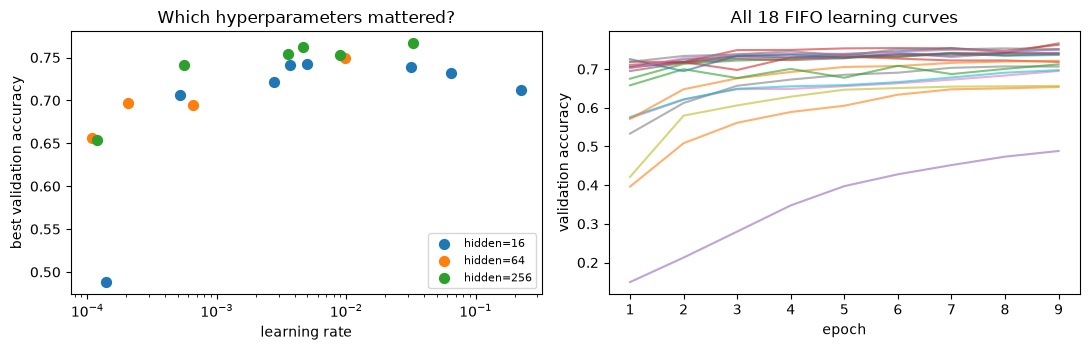

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for hidden, group in analysis.groupby("hidden"):
    axes[0].scatter(group["lr"], group["best val_acc"], s=50, label=f"hidden={hidden}")
axes[0].set(xscale="log", xlabel="learning rate", ylabel="best validation accuracy", title="Which hyperparameters mattered?")
axes[0].legend(fontsize=8)
all_reports = pd.concat([r.metrics_dataframe.assign(pool_id=r.config["pool_id"]) for r in fifo_results])
for pool_id, curve in all_reports.groupby("pool_id"):
    axes[1].plot(curve["epoch"], curve["val_acc"], alpha=0.6)
axes[1].set(xlabel="epoch", ylabel="validation accuracy", title="All 18 FIFO learning curves")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Using the `analysis` table, count the configs whose **best** epoch was **earlier than the last epoch** (`best epoch < MAX_EPOCHS`) — the ones where "take the last epoch" would have thrown away a better model. Store it in `peaked_early`.

In [29]:
peaked_early = None  # TODO: your code here
check("peaked_early", peaked_early, int((best_epoch_df["epoch"] < MAX_EPOCHS).sum()), hint="(analysis['best epoch'] < MAX_EPOCHS).sum()")

⏳ peaked_early: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
peaked_early = int((analysis["best epoch"] < MAX_EPOCHS).sum())
check("peaked_early", peaked_early, int((best_epoch_df["epoch"] < MAX_EPOCHS).sum()))
```

Validation accuracy is noisy and can drop when a model starts to overfit, so the best report is often not the last. Keep the best checkpoint (`checkpoint_score_attribute`) — but remember that picking the max over many noisy reports is itself optimistic (Pitfall 4).
</details>

> 💡 **Interview angle:** "How do you analyse an HPO run?" — look beyond the single best number: learning curves (did good trials still improve at `max_t`?), hyperparameter-vs-metric plots (is the best lr at the edge of the range → widen it), variance between similar configs (noise level), and confirm the winner on data the search never saw.

## 12. Where Ray Train Fits 🟢

Ray is a family of libraries on one runtime. Don't confuse the two training-related ones:

| Library | Distributes | Unit of work | Typical call |
|---|---|---|---|
| **Ray Tune** | **many** training runs with different hyperparameters | a trial (usually 1 process) | `tune.Tuner(trainable, ...)` |
| **Ray Train** | **one** training run across many workers/GPUs (data-parallel DDP, FSDP, …) | a worker group | `TorchTrainer(train_loop_per_worker, scaling_config=ScalingConfig(num_workers=8, use_gpu=True))` |
| Ray Data / Ray Serve | preprocessing pipelines / model serving | — | covered in the serving module |

**Combining them** — each trial *is* a distributed training job. In Ray 2.58 (Ray Train "V2", the default), the recommended pattern is to launch the trainer **inside** a Tune function trainable; passing a trainer object straight to `Tuner(trainer)` is deprecated since Ray 2.43. Adapted from the official guide (not executed here — it needs a multi-GPU cluster):

```python
import ray.train
from ray.train.torch import TorchTrainer
from ray.tune.integration.ray_train import TuneReportCallback

def train_loop_per_worker(train_loop_config):          # runs on EVERY training worker (DDP)
    ...                                                # prepare model/data, train an epoch
    ray.train.report({"val_loss": val_loss}, checkpoint=checkpoint)

def tune_trial(config):                                 # one Tune trial = one distributed training run
    trainer = TorchTrainer(
        train_loop_per_worker,
        train_loop_config=config,
        scaling_config=ray.train.ScalingConfig(num_workers=4, use_gpu=True),
        run_config=ray.train.RunConfig(callbacks=[TuneReportCallback()]),   # forwards reports to Tune
    )
    trainer.fit()

tuner = tune.Tuner(tune_trial, param_space={"lr": tune.loguniform(1e-5, 1e-3)},
                   tune_config=tune.TuneConfig(num_samples=8, max_concurrent_trials=2))  # 2 × 4 GPUs at a time
```

Inside the workers you call `ray.train.report`; `TuneReportCallback` passes those metrics up so Tune's schedulers can act on them. The trial driver function itself only reserves 1 CPU, so cap parallel trials with `max_concurrent_trials` to match your GPU count.

> 💡 **Interview angle:** "Ray Tune vs Ray Train?" — Tune runs many independent experiments (hyperparameter search); Train scales a single experiment over many devices. For a large model you often need both: each trial is a multi-GPU Train job, and Tune limits how many run at once.

## 🔧 Build It From Scratch

### 1) Successive halving on real data — no Ray

We implement successive halving ourselves and check its two promises: **much less compute** and **(near-)best config found**.

- **Pool:** 27 random `SGDClassifier` configs (a linear model trained by stochastic gradient descent) on the same Covertype split. `partial_fit` does one pass (epoch) over the data and can be called again to **continue** training — perfect for resuming survivors.
- **Reference:** train every config for the full **27 epochs** and record its validation accuracy after each epoch.
- **Successive halving:** budgets 1 → 3 → 9 → 27 epochs, keep the top 1/3 each time, continuing (not restarting) the survivors.

In [30]:
from types import SimpleNamespace

from ray.tune.schedulers.async_hyperband import _Bracket                # Ray's internal ASHA bookkeeping (used for part 2)
from sklearn.linear_model import SGDClassifier

N_CONFIGS, MAX_BUDGET, ETA = 27, 27, 3
sgd_rng = np.random.default_rng(SEED)
SGD_POOL = [{"alpha": float(10 ** sgd_rng.uniform(-6, -1)), "eta0": float(10 ** sgd_rng.uniform(-4, 0)),
             "loss": str(sgd_rng.choice(["hinge", "log_loss", "modified_huber"])),
             "learning_rate": str(sgd_rng.choice(["constant", "invscaling", "adaptive"]))} for _ in range(N_CONFIGS)]
CLASSES = np.unique(y_train)


def new_sgd(i):
    return SGDClassifier(**SGD_POOL[i], random_state=SEED), np.random.default_rng(i)   # model + its own shuffling RNG


def sgd_epoch(model, shuffle_rng):
    """One pass over the training data in a fresh random order; returns validation accuracy."""
    order = shuffle_rng.permutation(len(X_train))
    model.partial_fit(X_train[order], y_train[order], classes=CLASSES)
    return model.score(X_val, y_val)


# Reference: every config trained for the full budget
start = time.perf_counter()
full_curves = np.zeros((N_CONFIGS, MAX_BUDGET))
full_models = []
for i in range(N_CONFIGS):
    model, shuffle_rng = new_sgd(i)
    for epoch in range(MAX_BUDGET):
        full_curves[i, epoch] = sgd_epoch(model, shuffle_rng)
    full_models.append(model)
full_seconds = time.perf_counter() - start
full_epochs = N_CONFIGS * MAX_BUDGET


def successive_halving(n_configs, min_budget, max_budget, eta):
    """Synchronous successive halving with resumed training. Returns (winner, epochs used, rung log)."""
    state = {i: (*new_sgd(i), 0) for i in range(n_configs)}            # model, rng, epochs done
    alive, budget, epochs_used, log = list(range(n_configs)), min_budget, 0, []
    while True:
        scores = {}
        for i in alive:
            model, shuffle_rng, done = state[i]
            for _ in range(done, budget):                               # continue from where this config stopped
                scores[i] = sgd_epoch(model, shuffle_rng)
                epochs_used += 1
            state[i] = (model, shuffle_rng, budget)
        log.append((budget, len(alive)))
        if budget >= max_budget or len(alive) == 1:
            return max(alive, key=scores.get), epochs_used, log, scores
        alive = sorted(alive, key=scores.get, reverse=True)[:max(1, len(alive) // eta)]
        budget = min(max_budget, budget * eta)


start = time.perf_counter()
sh_winner, sh_epochs, sh_log, sh_scores = successive_halving(N_CONFIGS, 1, MAX_BUDGET, ETA)
sh_seconds = time.perf_counter() - start

final_acc = full_curves[:, -1]
sh_rank = int((final_acc > final_acc[sh_winner]).sum()) + 1
sh_regret = final_acc.max() - final_acc[sh_winner]
print("rungs (budget, configs):", sh_log)
print(f"train everything : {full_epochs} epochs, {full_seconds:.1f} s, best final acc {final_acc.max():.4f} (config {final_acc.argmax()})")
print(f"successive halving: {sh_epochs} epochs ({sh_epochs / full_epochs:.0%}), {sh_seconds:.1f} s, "
      f"winner config {sh_winner} → rank #{sh_rank} of {N_CONFIGS}, regret {sh_regret:.4f}")

assert sh_epochs == 27 * 1 + 9 * (3 - 1) + 3 * (9 - 3) + 1 * (27 - 9)   # 81 epochs: resumed training only pays the difference
assert np.isclose(sh_scores[sh_winner], full_curves[sh_winner, -1])     # resuming reproduces the full run exactly
assert sh_regret < 0.01, "successive halving should find a config within 1 point of the best"
print("✅ same final accuracy as the reference run for the winner; within 1 accuracy point of the best config")

rungs (budget, configs): [(1, 27), (3, 9), (9, 3), (27, 1)]
train everything : 729 epochs, 7.3 s, best final acc 0.7178 (config 8)
successive halving: 81 epochs (11%), 0.7 s, winner config 22 → rank #2 of 27, regret 0.0014
✅ same final accuracy as the reference run for the winner; within 1 accuracy point of the best config


### 2) The asynchronous ASHA rule — and a check against Ray's own implementation

ASHA never waits. When a trial reports at a rung milestone, it continues only if its score is **not below the (1 − 1/η) quantile** of the scores recorded at that rung *so far*. We replay the SGD learning curves as if trials reported **in a random asynchronous order**, feed every report to our rule and to Ray's internal `_Bracket` class (a private API — fine for a test, never for production code), and demand identical decisions.

In [31]:
class MyASHA:
    def __init__(self, grace_period, reduction_factor, max_t):
        self.rf = reduction_factor
        n_rungs = int(np.log(max_t / grace_period) / np.log(reduction_factor) + 1)
        self.rungs = {grace_period * reduction_factor ** k: {} for k in range(n_rungs)}   # milestone → {trial: score}

    def on_result(self, trial_id, iteration, score):
        for milestone in sorted(self.rungs, reverse=True):              # highest rung this report has passed
            recorded = self.rungs[milestone]
            if iteration < milestone or trial_id in recorded:
                continue
            cutoff = np.nanpercentile(list(recorded.values()), (1 - 1 / self.rf) * 100) if recorded else None
            recorded[trial_id] = score
            return "STOP" if cutoff is not None and score < cutoff else "CONTINUE"
        return "CONTINUE"


mine, ray_bracket = MyASHA(1, ETA, MAX_BUDGET), _Bracket(min_t=1, max_t=MAX_BUDGET, reduction_factor=ETA, s=0)
replay_rng = np.random.default_rng(7)
alive = set(range(N_CONFIGS))
decisions = agreements = async_epochs = 0
for epoch in range(1, MAX_BUDGET + 1):
    for i in replay_rng.permutation(N_CONFIGS):                       # reports arrive in a random order
        if i not in alive:
            continue
        async_epochs += 1
        score = full_curves[i, epoch - 1]
        ours = mine.on_result(str(i), epoch, score)
        theirs = ray_bracket.on_result(SimpleNamespace(trial_id=str(i)), epoch, score)
        decisions += 1
        agreements += ours == theirs
        if ours == "STOP" or epoch == MAX_BUDGET:
            alive.discard(i)

print(f"rung milestones: {sorted(mine.rungs)} (Ray: {sorted(m for m, _ in ray_bracket._rungs)})")
print(f"{agreements}/{decisions} decisions identical to Ray's ASHA bracket")
print(f"asynchronous replay used {async_epochs} epochs ({async_epochs / full_epochs:.0%} of training everything)")
assert agreements == decisions

rung milestones: [1, 3, 9, 27] (Ray: [1, 3, 9, 27])
167/167 decisions identical to Ray's ASHA bracket
asynchronous replay used 167 epochs (23% of training everything)


ASHA used more epochs than synchronous halving here: early trials are compared against few recorded scores, so it promotes more generously. That's the price of never waiting — and on a real cluster the idle time it avoids is worth far more.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — The wrong `mode` silently picks the worst trial

Tune can't know whether a metric should go up or down. Asking for `val_loss` with `mode="max"` returns a trial without any error.

In [32]:
worst = fifo_results.get_best_result(metric="val_loss", mode="max")      # ❌ loss should be minimised
right = fifo_results.get_best_result(metric="val_loss", mode="min")      # ✅
print(f"❌ mode='max' on val_loss → config {worst.config['pool_id']}: val_loss {worst.metrics['val_loss']:.3f}, val_acc {worst.metrics['val_acc']:.3f}")
print(f"✅ mode='min' on val_loss → config {right.config['pool_id']}: val_loss {right.metrics['val_loss']:.3f}, val_acc {right.metrics['val_acc']:.3f}")

❌ mode='max' on val_loss → config 14: val_loss 1.573, val_acc 0.488
✅ mode='min' on val_loss → config 17: val_loss 0.578, val_acc 0.751


### ❌ Pitfall 2 — Loading optimizer state undoes PBT's new learning rate

When PBT clones a trial, the clone gets the donor's checkpoint **and a new `lr` in its config**. `optimizer.load_state_dict` restores the donor's old learning rate too.

In [33]:
_, donor_optimizer = build_mlp({"lr": 0.1, "hidden": 16})
donor_state = donor_optimizer.state_dict()

_, clone_optimizer = build_mlp({"lr": 0.012, "hidden": 16})             # PBT "explore" chose lr = 0.012
clone_optimizer.load_state_dict(donor_state)
print("❌ lr after load_state_dict      :", clone_optimizer.param_groups[0]["lr"], "(exploration silently lost)")

for group in clone_optimizer.param_groups:                               # ✅ re-apply the config's lr (as train_mlp does)
    group["lr"] = 0.012
print("✅ lr after re-applying config lr:", clone_optimizer.param_groups[0]["lr"])

❌ lr after load_state_dict      : 0.1 (exploration silently lost)
✅ lr after re-applying config lr: 0.012


### ❌ Pitfall 3 — A trainable that ignores its checkpoint restarts from scratch

`FailureConfig` retries, HyperBand's pause/resume and PBT's cloning all hand the trial a checkpoint — but only **your code** can load it. `train_simple` (Section 2) never calls `tune.get_checkpoint()`. We crash it once after epoch 4 and count the epochs that were actually trained (each epoch appends a line to a log file).

In [34]:
def train_simple_flaky(config, data=None, marker=None):
    """train_simple (no checkpoint restore) that crashes once after epoch 4; logs every trained epoch."""
    real_report = tune.report

    def report_then_crash_once(metrics, checkpoint=None):
        with open(f"{marker}.epochs", "a") as log:
            log.write(f"{metrics['epoch']}\n")
        real_report(metrics, checkpoint=checkpoint)
        if metrics["epoch"] == 4 and not Path(marker).exists():
            Path(marker).touch()
            raise RuntimeError("deliberate worker crash after epoch 4")

    tune.report = report_then_crash_once
    try:
        train_simple(config, data)
    finally:
        tune.report = real_report


pitfall_marker = STORAGE / "crash_marker_no_resume"
with quiet_expected_failures():
    no_resume = tune.Tuner(tune.with_parameters(train_simple_flaky, data=DATA, marker=str(pitfall_marker)),
                           param_space={"lr": 3e-3, "hidden": 64, "batch_size": 256, "epochs": 8},
                           run_config=run_config("pitfall_no_resume", failure_config=tune.FailureConfig(max_failures=2))).fit()
trained_epochs = [int(line) for line in Path(f"{pitfall_marker}.epochs").read_text().split()]
print(f"❌ no checkpoint restore: trained {len(trained_epochs)} epochs for an 8-epoch trial — sequence {trained_epochs}")
print(f"✅ train_mlp (Section 10) restored its epoch-4 checkpoint: resumed_from = {int(retry_history['resumed_from'].iloc[-1])}, "
      f"so the retry trained only epochs 5–8")

❌ no checkpoint restore: trained 12 epochs for an 8-epoch trial — sequence [1, 2, 3, 4, 1, 2, 3, 4, 5, 6, 7, 8]
✅ train_mlp (Section 10) restored its epoch-4 checkpoint: resumed_from = 4, so the retry trained only epochs 5–8


With PBT the same bug is worse: a clone starts from random weights while claiming the donor's progress.

### ❌ Pitfall 4 — Reporting the best validation score as expected performance

Choosing the maximum of many noisy scores is biased upwards — the **winner's curse**. We split the validation set in two halves many times: pick the best SGD config on half A, then score *that* config on half B.

In [35]:
val_predictions = np.array([m.predict(X_val) for m in full_models])     # (27 configs, 5000 rows)
correct = val_predictions == y_val
gaps = []
split_rng = np.random.default_rng(SEED)
for _ in range(300):
    half = split_rng.permutation(len(y_val))
    a, b = half[: len(half) // 2], half[len(half) // 2:]
    chosen = correct[:, a].mean(axis=1).argmax()                           # ❌ select AND report on the same data
    gaps.append(correct[chosen, a].mean() - correct[chosen, b].mean())   # ✅ report on data not used for selection
gaps = np.array(gaps)
print(f"❌ selection-half accuracy exceeds fresh-half accuracy by {gaps.mean() * 100:+.2f} points on average "
      f"(positive in {np.mean(gaps > 0):.0%} of 300 splits)")
print("✅ report the chosen config on data the search never saw — a test set, touched once (the mini project does this)")

❌ selection-half accuracy exceeds fresh-half accuracy by +0.51 points on average (positive in 63% of 300 splits)
✅ report the chosen config on data the search never saw — a test set, touched once (the mini project does this)


### ❌ Pitfall 5 — Comparing strategies on different random configs

"Scheduler X found a better model than scheduler Y" means nothing if they tried different configs. The same random search, run on three different sets of 6 configs from our pool, gives noticeably different "best" results:

In [36]:
final_by_config = fifo_df["val_acc"].to_numpy()                       # true 9-epoch accuracy of each of the 18 configs
subset_best = [final_by_config[list(idx)].max() for idx in (range(0, 6), range(6, 12), range(12, 18))]
print("❌ best 9-epoch accuracy of three random-search runs with 6 configs each:", np.round(subset_best, 4),
      f"→ spread {max(subset_best) - min(subset_best):.4f} from luck alone")
print("✅ compare strategies on the same configs (Sections 5–6) or with equal budgets over several seeds, and report the spread")

❌ best 9-epoch accuracy of three random-search runs with 6 configs each: [0.7666 0.7364 0.7626] → spread 0.0302 from luck alone
✅ compare strategies on the same configs (Sections 5–6) or with equal budgets over several seeds, and report the spread


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — ASHA rung milestones
Write `asha_milestones(grace_period, reduction_factor, max_t)` returning the list of rung milestones Ray uses: `grace_period × reduction_factor**k` for `k = 0 … int(log(max_t / grace_period) / log(reduction_factor) + 1) - 1`.

In [37]:
def asha_milestones(grace_period, reduction_factor, max_t):
    return None  # TODO: your code here


got = None if asha_milestones(1, 3, 27) is None else [asha_milestones(1, 3, 27), asha_milestones(2, 2, 16)]
check("asha_milestones", got, [[1, 3, 9, 27], [2, 4, 8, 16]], hint="Compute the number of rungs first, then build the list with a comprehension.")

⏳ asha_milestones: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def asha_milestones(grace_period, reduction_factor, max_t):
    n_rungs = int(np.log(max_t / grace_period) / np.log(reduction_factor) + 1)
    return [grace_period * reduction_factor ** k for k in range(n_rungs)]


check("asha_milestones", [asha_milestones(1, 3, 27), asha_milestones(2, 2, 16)], [[1, 3, 9, 27], [2, 4, 8, 16]])
```
</details>

### 🟢 Exercise 2 — How many ASHA trials ran to the end?
Using `asha_df` from Section 5, count the trials whose `training_iteration` reached `MAX_EPOCHS`. Store it in `asha_finished`.

In [38]:
asha_finished = None  # TODO
check("asha_finished", asha_finished, int(sum(len(r.metrics_dataframe) == MAX_EPOCHS for r in asha_results)),
      hint="(asha_df['training_iteration'] == MAX_EPOCHS).sum()")

⏳ asha_finished: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
asha_finished = int((asha_df["training_iteration"] == MAX_EPOCHS).sum())
check("asha_finished", asha_finished, int(sum(len(r.metrics_dataframe) == MAX_EPOCHS for r in asha_results)))
```
</details>

### 🟢 Exercise 3 — Best LightGBM config by any report
From `lgb_results` (Section 8), get the `num_leaves` of the trial with the **lowest `val_logloss` at any report**. Store it in `best_num_leaves`.

In [39]:
best_num_leaves = None  # TODO
_lgb_best_rows = lgb_results.get_dataframe(filter_metric="val_logloss", filter_mode="min")
check("best_num_leaves", best_num_leaves, int(_lgb_best_rows.loc[_lgb_best_rows["val_logloss"].idxmin(), "config/num_leaves"]),
      hint="get_best_result(metric='val_logloss', mode='min', scope='all').config['num_leaves']")

⏳ best_num_leaves: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_num_leaves = lgb_results.get_best_result(metric="val_logloss", mode="min", scope="all").config["num_leaves"]
_lgb_best_rows = lgb_results.get_dataframe(filter_metric="val_logloss", filter_mode="min")
check("best_num_leaves", best_num_leaves, int(_lgb_best_rows.loc[_lgb_best_rows["val_logloss"].idxmin(), "config/num_leaves"]))
```
`scope="all"` matters with ASHA: a stopped trial's last report comes from fewer rounds than a finished trial's.
</details>

### 🟡 Exercise 4 — The compute bill of successive halving
Write `sh_total_epochs(n_configs, eta, min_budget, max_budget, resume)`: budgets start at `min_budget` and multiply by `eta` (capped at `max_budget`); after each rung keep `max(1, alive // eta)` configs. With `resume=True` a survivor only trains the *extra* epochs; with `resume=False` it restarts from scratch. Return the total epochs.

In [40]:
def sh_total_epochs(n_configs, eta, min_budget, max_budget, resume):
    return None  # TODO


got = None if sh_total_epochs(81, 3, 1, 81, True) is None else [sh_total_epochs(81, 3, 1, 81, True), sh_total_epochs(81, 3, 1, 81, False),
                                                                  sh_total_epochs(27, 3, 1, 27, True)]
check("sh_total_epochs", got, [297, 405, 81], hint="Loop over rungs: add alive × (budget − previous budget) when resuming, alive × budget otherwise.")

⏳ sh_total_epochs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def sh_total_epochs(n_configs, eta, min_budget, max_budget, resume):
    alive, budget, previous, total = n_configs, min_budget, 0, 0
    while True:
        total += alive * (budget - previous if resume else budget)
        if budget >= max_budget or alive == 1:
            return total
        previous, alive, budget = budget, max(1, alive // eta), min(max_budget, budget * eta)


check("sh_total_epochs", [sh_total_epochs(81, 3, 1, 81, True), sh_total_epochs(81, 3, 1, 81, False), sh_total_epochs(27, 3, 1, 27, True)], [297, 405, 81])
```
81 configs cost 297 epochs with resuming — about **3.7 full trials**, not "about one trial". Each rung costs roughly `n × min_budget` epochs, so the total grows with the number of rungs.
</details>

### 🟡 Exercise 5 — One PBT exploit/explore step
Write `pbt_step(scores, lrs, quantile_fraction, factors)`. Let `k = ceil(len(scores) × quantile_fraction)`. The k worst trials (worst first) copy the lr of the k best trials (best first) and multiply it by `factors[j]` for the j-th pair. Other trials keep their lr. Return the new list of lrs.

In [41]:
def pbt_step(scores, lrs, quantile_fraction, factors):
    return None  # TODO


check("pbt_step", pbt_step([0.7, 0.5, 0.9, 0.6, 0.8, 0.4], [0.01, 0.1, 0.003, 0.05, 0.02, 0.3], 1 / 3, [1.2, 0.8]),
      [0.01, 0.016, 0.003, 0.05, 0.02, 0.0036], hint="order = np.argsort(scores); bottom = order[:k]; top = order[::-1][:k]")

⏳ pbt_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def pbt_step(scores, lrs, quantile_fraction, factors):
    k = int(np.ceil(len(scores) * quantile_fraction))
    order = np.argsort(scores)
    bottom, top = order[:k], order[::-1][:k]
    new_lrs = list(lrs)
    for j, (loser, winner) in enumerate(zip(bottom, top)):
        new_lrs[loser] = lrs[winner] * factors[j]      # exploit (copy) + explore (perturb)
    return new_lrs


check("pbt_step", pbt_step([0.7, 0.5, 0.9, 0.6, 0.8, 0.4], [0.01, 0.1, 0.003, 0.05, 0.02, 0.3], 1 / 3, [1.2, 0.8]),
      [0.01, 0.016, 0.003, 0.05, 0.02, 0.0036])
```
In real PBT the loser also copies the winner's **weights** (checkpoint), and the factor is drawn at random from `perturbation_factors`.
</details>

### 🔴 Exercise 6 — HyperBand's bracket schedule (interview classic)
For maximum budget `R` and `eta`, HyperBand uses `s_max = floor(log_eta(R))` and `B = (s_max + 1) × R`. Each bracket `s = s_max, …, 0` starts `n = ceil(B / R × eta**s / (s + 1))` configs with budget `r = R × eta**(-s)`. Return the list of `(n, r)` pairs for `R = 81, eta = 3`. (Use integer arithmetic for `s_max` to avoid floating-point surprises.)

In [42]:
def hyperband_brackets(R, eta):
    return None  # TODO


check("hyperband_brackets", hyperband_brackets(81, 3), [(81, 1), (34, 3), (15, 9), (8, 27), (5, 81)],
      hint="s_max: count how many times you can multiply 1 by eta and stay ≤ R.")

⏳ hyperband_brackets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
import math


def hyperband_brackets(R, eta):
    s_max = 0
    while eta ** (s_max + 1) <= R:
        s_max += 1
    B = (s_max + 1) * R
    return [(math.ceil(B / R * eta ** s / (s + 1)), R // eta ** s) for s in range(s_max, -1, -1)]


check("hyperband_brackets", hyperband_brackets(81, 3), [(81, 1), (34, 3), (15, 9), (8, 27), (5, 81)])
```
The first bracket is aggressive successive halving (81 configs, judged after 1 epoch); the last is plain random search (5 configs, full budget). Each bracket uses roughly the same total budget B.
</details>

## 🚀 Mini Project: ASHA + Optuna vs Random Search + FIFO

**Goal:** tune a PyTorch MLP on Covertype two ways **with the same trial budget (20 trials, up to 12 epochs each)** and answer with measurements: does *smart search + early stopping* save compute, and does it hurt or help the final model?

| Strategy | Search algorithm | Scheduler |
|---|---|---|
| **A — baseline** | random search (`BasicVariantGenerator(random_state=0)`) | FIFO (every trial runs 12 epochs) |
| **B — smart** | `OptunaSearch` (TPE), at most 4 concurrent proposals | ASHA (`grace_period=2`, `reduction_factor=3`) |

**Protocol (no leakage):** trials train on *train* and are scored on *validation*. Each strategy's winner (best validation accuracy at any epoch) is **retrained on train + validation** for its best number of epochs, then evaluated **once** on the untouched *test* set.

### Step 1 — Search space and a runner

In [43]:
N_TRIALS, PROJECT_EPOCHS = 20, 12
PROJECT_SPACE = {"lr": tune.loguniform(1e-4, 3e-1), "hidden": tune.choice([32, 64, 128, 256]), "n_layers": tune.randint(1, 4),
                 "dropout": tune.uniform(0.0, 0.4), "batch_size": tune.choice([128, 256, 512]),
                 "weight_decay": tune.loguniform(1e-6, 1e-2), "epochs": PROJECT_EPOCHS}


def run_strategy(name, search_alg, scheduler):
    start = time.perf_counter()
    results = tune.Tuner(
        tune.with_parameters(train_mlp, data=DATA),
        param_space=PROJECT_SPACE,
        tune_config=tune.TuneConfig(metric="val_acc", mode="max", num_samples=N_TRIALS, search_alg=search_alg, scheduler=scheduler),
        run_config=run_config(name, checkpoint_config=tune.CheckpointConfig(num_to_keep=1)),
    ).fit()
    seconds = time.perf_counter() - start
    assert results.num_errors == 0, f"{results.num_errors} trials failed"
    best = results.get_best_result(scope="all")
    history = best.metrics_dataframe
    return {"results": results, "seconds": seconds, "best": best,
            "best_val_acc": float(history["val_acc"].max()), "best_epoch": int(history.loc[history["val_acc"].idxmax(), "epoch"]),
            "epochs": int(results.get_dataframe()["training_iteration"].sum())}

### Step 2 — Run both strategies

In [44]:
strategy_a = run_strategy("project_random_fifo", BasicVariantGenerator(random_state=SEED), None)
strategy_b = run_strategy("project_optuna_asha", ConcurrencyLimiter(OptunaSearch(seed=SEED), max_concurrent=4),
                          ASHAScheduler(max_t=PROJECT_EPOCHS, grace_period=2, reduction_factor=3))

project = pd.DataFrame({
    label: {"trials": N_TRIALS, "epochs trained": s["epochs"], "wall seconds": round(s["seconds"], 1),
            "best val_acc": round(s["best_val_acc"], 4), "best epoch": s["best_epoch"]}
    for label, s in [("A: random + FIFO", strategy_a), ("B: Optuna + ASHA", strategy_b)]
}).T
print(project.to_string())
for label, s in [("A", strategy_a), ("B", strategy_b)]:
    cfg = {k: (round(v, 5) if isinstance(v, float) else v) for k, v in s["best"].config.items() if k != "epochs"}
    print(f"winner {label}: {cfg}")

                  trials  epochs trained  wall seconds  best val_acc  best epoch
A: random + FIFO    20.0           240.0          25.1        0.7654        12.0
B: Optuna + ASHA    20.0            96.0          26.9        0.7568        12.0
winner A: {'lr': 0.0011, 'hidden': 64, 'n_layers': 2, 'dropout': 0.01133, 'batch_size': 128, 'weight_decay': 0.00048}
winner B: {'lr': 0.00947, 'hidden': 64, 'n_layers': 3, 'dropout': 0.27273, 'batch_size': 512, 'weight_decay': 0.0}


### Step 3 — Anytime performance: best validation accuracy vs compute spent

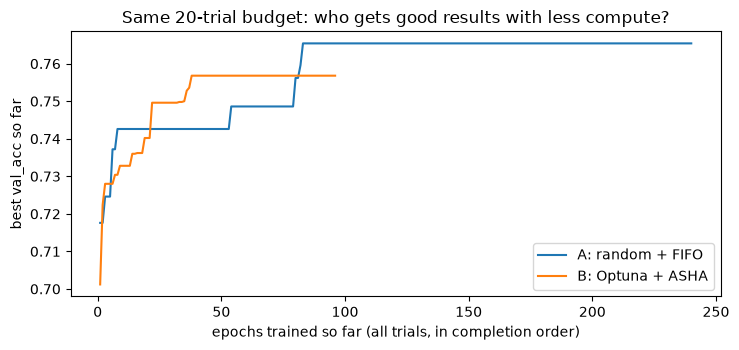

In [45]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for label, s in [("A: random + FIFO", strategy_a), ("B: Optuna + ASHA", strategy_b)]:
    reports = pd.concat([r.metrics_dataframe[["timestamp", "val_acc"]] for r in s["results"]]).sort_values("timestamp", kind="stable")
    ax.plot(np.arange(1, len(reports) + 1), reports["val_acc"].cummax().to_numpy(), label=label)
ax.set(xlabel="epochs trained so far (all trials, in completion order)", ylabel="best val_acc so far",
       title="Same 20-trial budget: who gets good results with less compute?")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Retrain each winner on train + validation, evaluate once on test

In [46]:
X_train_full = torch.tensor(np.concatenate([X_train, X_val]))
y_train_full = torch.tensor(np.concatenate([y_train, y_val]))
X_test_t, y_test_t = torch.tensor(X_test), torch.tensor(y_test)


def retrain_and_predict(config, epochs):
    model, optimizer = build_mlp(config)
    generator = torch.Generator().manual_seed(config.get("seed", SEED))
    for _ in range(epochs):
        train_one_epoch(model, optimizer, X_train_full, y_train_full, config["batch_size"], generator)
    model.eval()
    with torch.no_grad():
        return model(X_test_t).argmax(dim=1).numpy()


test_pred = {}
for label, s in [("A", strategy_a), ("B", strategy_b)]:
    test_pred[label] = retrain_and_predict(s["best"].config, s["best_epoch"])
    s["test_acc"] = float(np.mean(test_pred[label] == y_test))
    print(f"strategy {label}: retrained {s['best_epoch']} epochs on {len(y_train_full):,} rows → TEST accuracy {s['test_acc']:.4f} "
          f"(val was {s['best_val_acc']:.4f})")

# Paired bootstrap: is the test difference bigger than sampling noise?
boot_rng = np.random.default_rng(SEED)
correct_a, correct_b = test_pred["A"] == y_test, test_pred["B"] == y_test
diffs = np.array([(correct_b[idx].mean() - correct_a[idx].mean()) for idx in boot_rng.integers(0, len(y_test), (2000, len(y_test)))])
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"test accuracy B − A = {correct_b.mean() - correct_a.mean():+.4f}, 95% bootstrap CI [{ci_low:+.4f}, {ci_high:+.4f}]")

strategy A: retrained 12 epochs on 21,000 rows → TEST accuracy 0.7742 (val was 0.7654)


strategy B: retrained 12 epochs on 21,000 rows → TEST accuracy 0.7534 (val was 0.7568)
test accuracy B − A = -0.0208, 95% bootstrap CI [-0.0298, -0.0122]


### Step 5 — Conclusions computed from the numbers

In [47]:
epoch_ratio = strategy_b["epochs"] / strategy_a["epochs"]
time_ratio = strategy_b["seconds"] / strategy_a["seconds"]
print(f"• Compute: Optuna + ASHA trained {strategy_b['epochs']} epochs vs {strategy_a['epochs']} ({epoch_ratio:.0%}) "
      f"and took {time_ratio:.0%} of the wall time.")
val_gap = strategy_b["best_val_acc"] - strategy_a["best_val_acc"]
print(f"• Validation: best val_acc {strategy_b['best_val_acc']:.4f} (B) vs {strategy_a['best_val_acc']:.4f} (A) → difference {val_gap:+.4f}.")
if ci_low > 0:
    verdict = "B's winner is significantly better on test"
elif ci_high < 0:
    verdict = "A's winner is significantly better on test"
else:
    verdict = "the test accuracies are statistically indistinguishable (the CI includes 0)"
print(f"• Test (touched once per winner): {strategy_b['test_acc']:.4f} (B) vs {strategy_a['test_acc']:.4f} (A) → {verdict}.")
if epoch_ratio < 1 and ci_high >= 0:
    print(f"• Bottom line: smart search + early stopping used {1 - epoch_ratio:.0%} fewer epochs without a significant loss in test accuracy.")
else:
    print("• Bottom line: on this run the compute saving did not come for free — check the per-trial curves before trusting ASHA here.")
for label, s in [("A", strategy_a), ("B", strategy_b)]:
    if s["best_epoch"] == PROJECT_EPOCHS:
        print(f"• Winner {label} peaked at the last allowed epoch ({PROJECT_EPOCHS}): it was probably still improving, so a larger max_t is worth trying.")
print("• One run of each strategy is an anecdote: ASHA's arrival-order effects and TPE's randomness change results between runs (stretch goal 1).")

• Compute: Optuna + ASHA trained 96 epochs vs 240 (40%) and took 107% of the wall time.
• Validation: best val_acc 0.7568 (B) vs 0.7654 (A) → difference -0.0086.
• Test (touched once per winner): 0.7534 (B) vs 0.7742 (A) → A's winner is significantly better on test.
• Bottom line: on this run the compute saving did not come for free — check the per-trial curves before trusting ASHA here.
• Winner A peaked at the last allowed epoch (12): it was probably still improving, so a larger max_t is worth trying.
• Winner B peaked at the last allowed epoch (12): it was probably still improving, so a larger max_t is worth trying.
• One run of each strategy is an anecdote: ASHA's arrival-order effects and TPE's randomness change results between runs (stretch goal 1).


**Stretch goals**
1. Repeat both strategies with 3 different seeds and report mean ± std of epochs, wall time, and test accuracy — one run of each is an anecdote.
2. Add a third strategy, **random search + ASHA**, to separate the effect of the searcher from the effect of the scheduler.
3. Raise `N_TRIALS` to 60 and `max_concurrent` to 16: does TPE still beat random search when most proposals are made without feedback?
4. Replace the MLP with the LightGBM trainable from Section 8 and redo the comparison on boosting rounds.

### 🗣️ How to talk about this in an interview
- "I compared **random search + FIFO** with **TPE + ASHA** at an equal budget of 20 trials on Covertype, keeping train/validation/test strictly separate and touching test once per winner."
- "I measured compute as total epochs and wall time, and judged quality with a **paired bootstrap CI** on test accuracy instead of eyeballing a single number — so I could say whether the compute saving cost accuracy, not just assume it didn't."
- "The trainable is resumable: per-epoch checkpoints with optimizer state, which is what lets ASHA stop, HyperBand pause, PBT clone, and `FailureConfig` retry."
- "I retrained the winner on train + validation for its best epoch count before the final test evaluation, so the reported number isn't the optimistic validation maximum."
- "Next I'd repeat with several seeds and separate searcher vs scheduler effects with a random + ASHA arm."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Ray Tune or Optuna — which would you pick, and when?**

<details><summary>Show answer</summary>

- **30-second answer:** Optuna for single-machine studies with a simple API, define-by-run search spaces, and pruning. Ray Tune when trials must run in parallel across many CPUs/GPUs or nodes, need resource scheduling, fault tolerance, or schedulers like ASHA and PBT. They combine: `OptunaSearch` gives Tune Optuna's TPE sampler.
- **Go deeper:** Optuna can also parallelise through a shared RDB storage, but you manage the workers yourself. Tune manages placement (`with_resources`), checkpoint syncing to shared storage, retries, and restores.
- **❌ Common wrong answer:** "Ray Tune is always better because it's distributed" — for 50 quick trials on one laptop it just adds start-up overhead (Section 2 measured exactly that).

</details>

**Q2. Explain successive halving and ASHA. What do `grace_period` and `reduction_factor` control?**

<details><summary>Show answer</summary>

- **30-second answer:** Start many configs with a small budget, keep the top 1/η at each rung, give survivors η× more budget. `grace_period` is the first rung (minimum budget before stopping), `reduction_factor` is η (how aggressively to cut and how far apart rungs are). ASHA makes the decision asynchronously when each trial reaches a rung, comparing it to the scores recorded there so far — no waiting for stragglers.
- **Go deeper:** Rungs sit at `grace_period × η^k` up to `max_t`. Ray's defaults are `grace_period=1`, `reduction_factor=4`, `max_t=100`. Async decisions depend on arrival order; early trials face fewer competitors.
- **❌ Common wrong answer:** "ASHA costs about the same as one full trial." Measured: 81 configs cost ~297 epochs (≈3.7 full runs) with resumed training.

</details>

**Q3. What problem does HyperBand solve on top of successive halving?**

<details><summary>Show answer</summary>

- **30-second answer:** SH forces you to choose how many configs to start vs how much budget each gets before judging (the "n vs B/n" trade-off). HyperBand runs several SH brackets from very aggressive (many configs, early cuts) to none (few configs, full budget), so a bad guess about when learning curves become informative isn't fatal.
- **Go deeper:** Each bracket uses roughly the same total budget; Exercise 6 computes the schedule. BOHB replaces HyperBand's random sampling with a model-based (TPE-like) sampler. In Ray, `HyperBandScheduler` is synchronous (pauses trials); `ASHAScheduler(brackets>1)` is the async version.
- **❌ Common wrong answer:** "HyperBand is just successive halving with a different reduction factor."

</details>

**Q4. How does Population Based Training work, and what do you get at the end?**

<details><summary>Show answer</summary>

- **30-second answer:** A population trains in parallel. Every `perturbation_interval`, trials in the bottom quantile copy the checkpoint of a top-quantile trial (exploit) and perturb or resample its hyperparameters (explore). You get a trained model plus a hyperparameter **schedule**, found at roughly the cost of training the population once.
- **Go deeper:** Requires checkpointing and restoring optimizer state (then re-applying the new lr). Popular for RL and long training runs; not reproducible from one static config (Ray offers PBT replay of the schedule). Keep enough checkpoints — deleting a donor's checkpoint breaks cloning.
- **❌ Common wrong answer:** "PBT is a genetic algorithm that trains every generation from scratch."

</details>

**Q5. What's the difference between a search algorithm and a scheduler, and why use a concurrency limit with Bayesian search?**

<details><summary>Show answer</summary>

- **30-second answer:** The search algorithm picks *which* configs to try (random, grid, TPE, BOHB); the scheduler decides *how long* trials run (FIFO, ASHA, HyperBand, PBT). Model-based searchers learn from completed results; with too many concurrent trials, most proposals are made blind, degrading to random search — `ConcurrencyLimiter` or `max_concurrent_trials` keeps feedback flowing.
- **Go deeper:** With ASHA, the searcher also receives results of early-stopped trials; TPE treats those as (pessimistic) observations. Warm-start with `points_to_evaluate` to encode known good configs.
- **❌ Common wrong answer:** "ASHA chooses the next hyperparameters."

</details>

**Q6. Why is the best validation score from a tuning run an optimistic estimate, and how do you report performance honestly?**

<details><summary>Show answer</summary>

- **30-second answer:** Picking the maximum of many noisy scores selects configs that got lucky on that validation set (winner's curse). Report the chosen config on data not used for selection — a held-out test set evaluated once, or nested cross-validation.
- **Go deeper:** Pitfall 4 measured a consistently positive gap between selection-half and fresh-half accuracy. The bias grows with the number of trials and shrinks with bigger validation sets. Also choose the epoch/checkpoint on validation, never test.
- **❌ Common wrong answer:** "Validation data is unseen by the model, so its score is unbiased."

</details>

### 💻 Coding

**Q7. Write a Ray Tune function trainable that reports validation loss each epoch and resumes from a checkpoint.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def trainable(config):
      model, opt = build(config); start = 0
      if (ckpt := tune.get_checkpoint()):
          with ckpt.as_directory() as d:
              state = torch.load(Path(d) / "state.pt")
          model.load_state_dict(state["model"]); opt.load_state_dict(state["opt"]); start = state["epoch"]
      for epoch in range(start, config["epochs"]):
          train_one_epoch(model, opt); val_loss = evaluate(model)
          with tempfile.TemporaryDirectory() as d:
              torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch + 1}, Path(d) / "state.pt")
              tune.report({"val_loss": val_loss}, checkpoint=tune.Checkpoint.from_directory(d))
  ```
- **Go deeper:** `tune.report(metrics_dict, checkpoint=...)` is the Ray 2.x signature; `tune.checkpoint_dir` and keyword-style `tune.report(loss=...)` are Ray 1.x. Pass data with `tune.with_parameters`. Set `CheckpointConfig(num_to_keep=...)` except with PBT.
- **❌ Common wrong answer:** Saving only the model weights, or writing checkpoints to a path only one node can see.

</details>

**Q8. How do you give each trial 2 CPUs and half a GPU, run at most 4 trials, and pass a 2 GB dataset efficiently?**

<details><summary>Show answer</summary>

- **30-second answer:** `tune.Tuner(tune.with_resources(tune.with_parameters(train, data=data), {"cpu": 2, "gpu": 0.5}), tune_config=tune.TuneConfig(max_concurrent_trials=4, ...))`. `with_parameters` puts the data in Ray's object store once instead of pickling it into every trial.
- **Go deeper:** Half a GPU is bookkeeping — two trials share the device, so each must fit in half the memory. Ray sets `CUDA_VISIBLE_DEVICES` and `OMP_NUM_THREADS` per trial. For huge data, load inside the trial from shared storage or use Ray Data.
- **❌ Common wrong answer:** Reading a global DataFrame inside the trainable (it gets serialized with the function) or assuming `gpu: 0.5` isolates memory.

</details>

### 🐛 Debugging Scenarios

**Q9. On a 32-core machine, 8 parallel trials each take 5× longer than one trial alone. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** CPU oversubscription: every trial spawns many threads (e.g. `n_jobs=-1`, PyTorch/BLAS pools sized to all cores), so 8 trials start ~250 threads on 32 cores. Request resources per trial and match library threads to them (`n_jobs`, `num_threads`, `torch.set_num_threads`).
- **Go deeper:** Ray sets `OMP_NUM_THREADS` to the trial's CPU count (Section 9 measured 1 and 2), but libraries with their own thread settings (`n_jobs=-1`, LightGBM `num_threads`) still need them set. Also check memory swapping and data loading bottlenecks.
- **❌ Common wrong answer:** "Ray only uses one core unless you call `ray.init()`." (`Tuner.fit()` starts Ray automatically and uses all detected CPUs.)

</details>

**Q10. Your PBT run fails with "Could not recover from checkpoint as it does not exist on storage anymore", or the learning rate never really changes. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** The first means donors' checkpoints were deleted before clones loaded them — raise or remove `CheckpointConfig(num_to_keep)`. The second usually means the trainable restores optimizer state after reading the new config, overwriting the explored lr — re-apply `config["lr"]` to `param_groups` after `load_state_dict`.
- **Go deeper:** Also confirm the trainable restores from `tune.get_checkpoint()` at all (otherwise clones restart from scratch), that `perturbation_interval` is in units of `time_attr`, and that mutated keys appear in `hyperparam_mutations`.
- **❌ Common wrong answer:** "PBT is random, just run it longer."

</details>

**Q11. ASHA picked a config that performs worse than one you know is good. Why might that happen?**

<details><summary>Show answer</summary>

- **30-second answer:** The good config was a late bloomer (e.g. small learning rate, warm-up schedule) and got stopped at an early rung, or noisy early metrics misranked it. Increase `grace_period`, use HyperBand/multiple brackets, report a smoother metric, or add the known config via `points_to_evaluate`.
- **Go deeper:** Run FIFO on the same configs once (Section 5) to measure ASHA's regret on your problem. Also check `mode`, that `time_attr` matches the unit you think (iterations vs seconds), and that the trainable resumes from checkpoints (Pitfall 3).
- **❌ Common wrong answer:** "ASHA has a bug; always use FIFO."

</details>

**Q12. A node dies halfway through a two-day tuning job. How do you recover without starting over?**

<details><summary>Show answer</summary>

- **30-second answer:** If trials checkpoint and `FailureConfig(max_failures>0)` is set, Tune retries affected trials from their latest checkpoint automatically. If the driver died, `tune.Tuner.restore(path, trainable, resume_errored=True).fit()` reloads experiment state from `storage_path` and resumes unfinished trials.
- **Go deeper:** On clusters, `storage_path` must be shared/cloud storage. Use `Tuner.can_restore(path)` in job scripts to decide between restore and a fresh run. `restart_errored=True` restarts errored trials from scratch.
- **❌ Common wrong answer:** "Set a random seed and rerun everything."

</details>

### 🏗️ Design

**Q13. You have 16 GPUs for 48 hours to tune a model whose full training takes 6 GPU-hours. Design the HPO.**

<details><summary>Show answer</summary>

- **30-second answer:** 768 GPU-hours ≈ 128 full runs. Narrow the space with small-scale proxy runs first; then run ASHA (or BOHB) with `max_t` = full training, `grace_period` ≈ 5–10% of it, η = 3, TPE or random proposals with a concurrency limit around 16, 1 GPU per trial, per-epoch checkpoints on shared storage, `FailureConfig` for preemptions. Retrain the winner (a few seeds) and evaluate on a held-out test set.
- **Go deeper:** Consider PBT if the lr schedule matters; log to MLflow/W&B via callbacks; budget ~20% for final retraining and seed variance; for multi-GPU trials, launch Ray Train inside each trial and cap `max_concurrent_trials`.
- **❌ Common wrong answer:** "Grid search over 5 hyperparameters × 4 values" (1,024 full runs — 8× over budget).

</details>

**Q14. When would you use Ray Train with Ray Tune, and how do they fit together?**

<details><summary>Show answer</summary>

- **30-second answer:** When a single trial needs several GPUs/nodes (data-parallel or sharded training). Ray Train distributes one run; Tune runs many. In Ray 2.43+, launch `TorchTrainer(...).fit()` inside a Tune function trainable with `TuneReportCallback`, and limit `max_concurrent_trials` to fit the cluster.
- **Go deeper:** Workers call `ray.train.report`; the callback forwards metrics so Tune schedulers can stop trials. Passing a trainer directly to `Tuner(trainer)` is the deprecated pattern.
- **❌ Common wrong answer:** "Ray Train and Ray Tune are the same thing."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** Rung milestones of `ASHAScheduler(max_t=81, grace_period=1, reduction_factor=3)`?
<details><summary>Answer</summary>

`[1, 3, 9, 27, 81]` — `grace_period × 3^k` up to `max_t`.
</details>

**2.** The largest value `tune.randint(1, 5)` can return?
<details><summary>Answer</summary>

`4` — the upper bound is exclusive.
</details>

**3.** `param_space={"lr": tune.grid_search([1e-3, 1e-2, 1e-1]), "dropout": tune.uniform(0, 0.5)}` with `num_samples=2` — how many trials?
<details><summary>Answer</summary>

`6` — 3 grid values × 2 samples.
</details>

**4.** `ray.init(num_cpus=4)` and `tune.with_resources(trainable, {"cpu": 2})` — how many trials run at once?
<details><summary>Answer</summary>

`2`.
</details>

**5.** What does `results.get_best_result()` compare by default: each trial's best report or last report?
<details><summary>Answer</summary>

The **last** report (`scope="last"`). Use `scope="all"` to consider every report.
</details>

## 📚 Resources

### 📖 Official Docs
- [Ray Tune: Hyperparameter Tuning](https://docs.ray.io/en/latest/tune/index.html) — overview and user guides
- [Getting Started with Ray Tune](https://docs.ray.io/en/latest/tune/getting-started.html) — a PyTorch example end to end
- [Key Concepts of Ray Tune](https://docs.ray.io/en/latest/tune/key-concepts.html) — trainables, search spaces, searchers, schedulers, ResultGrid
- [Tune Trial Schedulers](https://docs.ray.io/en/latest/tune/api/schedulers.html) — ASHA, HyperBand, PBT, and their arguments
- [Tune Search Algorithms](https://docs.ray.io/en/latest/tune/api/suggestion.html) — OptunaSearch, ConcurrencyLimiter, and others
- [How to Save and Load Trial Checkpoints](https://docs.ray.io/en/latest/tune/tutorials/tune-trial-checkpoints.html) and [How to Enable Fault Tolerance in Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-fault-tolerance.html)
- [A Guide to Population Based Training with Tune](https://docs.ray.io/en/latest/tune/examples/pbt_guide.html) — PBT in practice
- [Hyperparameter Tuning with Ray Tune (Ray Train guide)](https://docs.ray.io/en/latest/train/user-guides/hyperparameter-optimization.html) — the current Train-inside-Tune pattern

### 🎥 Videos
- [Modzy — Hyperparameter Optimization with Ray Tune](https://www.youtube.com/watch?v=YBJd8BQWK8Q) (28 min) — a walkthrough of Tune's concepts and schedulers; good after Sections 1–5
- [Anyscale — Anyscale Connect: Population Based Training with Ray Tune](https://www.youtube.com/watch?v=iBVveUT72jU) (41 min) — PBT explained by the Ray team, with practical advice; watch after Section 7
- [AIxplained — Automated Machine Learning - Successive Halving and Hyperband](https://www.youtube.com/watch?v=JUrU92fTxpo) (18 min) — a lecture deriving SH and HyperBand budgets; pairs with the Build It From Scratch section and Exercise 6

### 📄 Papers
- [Jamieson & Talwalkar (2016) — Non-stochastic Best Arm Identification and Hyperparameter Optimization](https://arxiv.org/abs/1502.07943) — successive halving for HPO
- [Li et al. (2018) — Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization](https://arxiv.org/abs/1603.06560) — HyperBand
- [Li et al. (2020) — A System for Massively Parallel Hyperparameter Tuning](https://arxiv.org/abs/1810.05934) — ASHA
- [Jaderberg et al. (2017) — Population Based Training of Neural Networks](https://arxiv.org/abs/1711.09846) — PBT
- [Liaw et al. (2018) — Tune: A Research Platform for Distributed Model Selection and Training](https://arxiv.org/abs/1807.05118) — the Ray Tune paper

### 📘 Books & Courses
- [Hyperparameter tuning using Ray Tune — PyTorch Tutorials](https://docs.pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html) — the official PyTorch tutorial (CIFAR-10 with ASHA)
- [Optuna: A hyperparameter optimization framework](https://optuna.readthedocs.io/en/stable/index.html) — the TPE sampler and pruners behind `OptunaSearch`

### 🏋️ Practice
- [Ray Tune Examples](https://docs.ray.io/en/latest/tune/examples/index.html) — runnable examples for PyTorch, XGBoost, LightGBM, Keras, and more: pick one and add ASHA + checkpointing
- [ray-project/ray on GitHub](https://github.com/ray-project/ray) — read `python/ray/tune/schedulers/async_hyperband.py` (~300 lines) and compare with your `MyASHA`

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Start Ray | local or cluster runtime | `ray.init(num_cpus=4, address="local")` · `ray.shutdown()` |
| Trainable | your training code | `def f(config): ... tune.report({"val_acc": acc}, checkpoint=...)` |
| Data to trials | object store, once | `tune.with_parameters(f, data=DATA)` |
| Search space | what to sample | `uniform`, `loguniform`, `randint` (high excluded), `lograndint`, `choice`, `grid_search` |
| Run | trials in parallel | `tune.Tuner(f, param_space=..., tune_config=tune.TuneConfig(metric, mode, num_samples, search_alg, scheduler), run_config=tune.RunConfig(name, storage_path))` |
| Checkpoints | resume / best epoch | `tune.get_checkpoint()`, `Checkpoint.from_directory`, `CheckpointConfig(num_to_keep, checkpoint_score_attribute)` |
| ASHA | async successive halving | `ASHAScheduler(max_t, grace_period, reduction_factor)` — rungs `grace × η^k` |
| HyperBand | brackets of SH | `HyperBandScheduler(max_t, reduction_factor)` (synchronous, pauses trials) |
| PBT | exploit + explore during training | `PopulationBasedTraining(perturbation_interval, hyperparam_mutations)` — needs checkpoints |
| Smart search | TPE with feedback | `ConcurrencyLimiter(OptunaSearch(seed=0), max_concurrent=4)` |
| Resources | CPUs/GPUs per trial | `tune.with_resources(f, {"cpu": 2, "gpu": 0.5})`, `max_concurrent_trials` |
| Fault tolerance | survive crashes | `RunConfig(failure_config=tune.FailureConfig(max_failures=2))`, `Tuner.restore(path, f, resume_errored=True)` |
| Analysis | read results | `get_best_result(scope=...)`, `get_dataframe(filter_metric, filter_mode)`, `result.metrics_dataframe` |
| Ray Train | one run on many GPUs | `TorchTrainer(...).fit()` inside a Tune trial + `TuneReportCallback` |

## ➡️ What's Next

**[03 · AutoGluon](03_AutoGluon.ipynb)** *(optional)* — instead of tuning one model family yourself, let an AutoML system train, bag, and stack many models under a time budget, and learn when that's a strong baseline versus a final model. Or jump to **[Capstone: End-to-End ML Project](../13_Capstone_Projects/01_End_to_End_ML_Project.ipynb)** to use tuning inside a complete project.

The cell below shuts Ray down and frees its worker processes — always do this when you're done.

In [48]:
ray.shutdown()
print("Ray shut down:", not ray.is_initialized())

Ray shut down: True
